In [9]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.cm as cm
from matplotlib.patches import Patch, ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib import gridspec
from scipy.spatial import Voronoi, cKDTree
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import random

In [10]:
sns.set_theme(style="ticks", font_scale=1.6)
CALL_TYPE_COLORS = {'alarm': (0.2823529411764706, 0.47058823529411764, 0.8156862745098039), 
                    'contact': (0.9333333333333333, 0.5215686274509804, 0.2901960784313726), 
                    'departure': (0.41568627450980394, 0.8, 0.39215686274509803), 
                    'distance': (0.8392156862745098, 0.37254901960784315, 0.37254901960784315), 
                    'recruitment': (0.5843137254901961, 0.4235294117647059, 0.7058823529411765), 
                    'triumph': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882)}
DOT_SIZE = 10
ALPHA = .6

In [11]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [12]:
def scatter_projections(
    syllables=None,
    projection=None,
    labels=None,
    ax=None,
    figsize=(10, 10),
    alpha=0.1,
    s=1,
    color="k",
    color_palette="tab20",
    categorical_labels=True,
    show_legend=True,
    tick_pos="bottom",
    tick_size=16,
    cbar_orientation="vertical",
    log_x=False,
    log_y=False,
    grey_unlabelled=True,
    fig=None,
    colornorm=False,
    rasterized=True,
    equalize_axes=True,
    print_lab_dict=False,  # prints color scheme
    lab_dict=CALL_TYPE_COLORS,
):
    """ 
    creates a scatterplot of syllables using some projection
    From Sainburg et al. 2020: https://github.com/timsainb/avgn_paper/blob/V2/avgn/visualization/projections.py
    """
    if projection is None and syllables is None:
            raise ValueError("Either syllables or projections must be passed")

    # color labels
    if labels is not None:
        if categorical_labels:
            if lab_dict is None:
                if (color_palette == "tab10") & (len(np.unique(labels)) < 10):
                    pal = sns.color_palette(color_palette, n_colors=10)
                    pal = np.array(pal)[
                        np.linspace(0, 9, len(np.unique(labels))).astype("int")
                    ]
                else:
                    pal = sns.color_palette(color_palette, n_colors=len(np.unique(labels)))
                lab_dict = {lab: pal[i] for i, lab in enumerate(np.unique(labels))}

            if grey_unlabelled and -1 in lab_dict:
                lab_dict[-1] = [0.95, 0.95, 0.95, 1.0]

            if print_lab_dict:
                print(lab_dict)

            colors = np.array([lab_dict[i] for i in labels])
        else:
            colors = labels  # continuous case
    else:
        colors = color

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if colornorm:
        norm = LogNorm()
    else:
        norm = None

    if categorical_labels or labels is None:
        ax.scatter(
            projection[:, 0],
            projection[:, 1],
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            color=colors,
            norm=norm,
        )

    else:
        cmin = np.quantile(labels, 0.01)
        cmax = np.quantile(labels, 0.99)
        sct = ax.scatter(
            projection[:, 0],
            projection[:, 1],
            vmin=cmin,
            vmax=cmax,
            cmap=plt.get_cmap(color_palette),
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            c=labels,
        )

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(1.5)

    if labels is not None:
        if categorical_labels == True:
            legend_elements = [
                Line2D([0], [0], marker="o", color=value, label=key)
                for key, value in lab_dict.items()
            ]
        if show_legend:
            if not categorical_labels:
                if cbar_orientation == "horizontal":
                    axins1 = inset_axes(
                        ax,
                        width="50%",  # width = 50% of parent_bbox width
                        height="5%",  # height : 5%
                        loc="upper left",
                    )
                    # cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation

                else:
                    axins1 = inset_axes(
                        ax,
                        width="5%",  # width = 50% of parent_bbox width
                        height="50%",  # height : 5%
                        loc="lower right",
                    )
                cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation)
                cbar.ax.tick_params(labelsize=tick_size)
                axins1.xaxis.set_ticks_position(tick_pos)
            else:
                ax.legend(handles=legend_elements)
    if equalize_axes:
        ax.axis("equal")
    return ax

def scatter_spec(
    z,
    specs,
    column_size=10,
    pal_color="hls",
    matshow_kwargs={"cmap": plt.cm.Greys},
    scatter_kwargs={"alpha": 0.5, "s": 1},
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 1},
    color_points=False,
    figsize=(10, 10),
    range_pad=0.1,
    x_range=None,
    y_range=None,
    enlarge_points=0,
    draw_lines=True,
    n_subset=-1,
    ax=None,
    show_scatter=True,
    border_line_width=1,
    img_origin="lower",
):
    n_columns = column_size * 4 - 4
    pal = sns.color_palette(pal_color, n_colors=n_columns)

    if ax is None:
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(column_size, column_size)
        main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])

    else:
        fig = ax.figure

       # get subplot bbox in figure coordinates
        bbox = ax.get_position()
        width = bbox.width
        height = bbox.height
        side = min(width, height)

        # center a square in subplot
        cx = bbox.x0 + width/2
        cy = bbox.y0 + height/2
        square_bbox = [cx - side/2, cy - side/2, side, side]

        # main_ax remains the user-passed ax
        main_ax.set_position(square_bbox)

        # now build the ring of small axes manually in figure coordinates
        n_thumbs = len(specs)  # or column_size*4-4
        for i, spec in enumerate(specs):
            # compute row/col in ring as before
            row, col = ... 
            x0 = square_bbox[0] + (col / column_size) * side
            y0 = square_bbox[1] + (row / column_size) * side
            ax_small = fig.add_axes([x0, y0, side/column_size, side/column_size])
            ax_small.matshow(spec, origin="lower", cmap="binary")
            ax_small.set_xticks([])
            ax_small.set_yticks([])
            for spine in ax_small.spines.values():
                spine.set_edgecolor('grey')
                spine.set_linewidth(1.5)

    fig.patch.set_alpha(0)

    # Determine plotting range
    if x_range is None and y_range is None:
        z_arr = np.vstack(z)
        x_sorted = np.sort(z_arr[:, 0])
        y_sorted = np.sort(z_arr[:, 1])
        xmin, xmax = x_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        ymin, ymax = y_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        xmin -= (xmax - xmin) * range_pad
        xmax += (xmax - xmin) * range_pad
        ymin -= (ymax - ymin) * range_pad
        ymax += (ymax - ymin) * range_pad
    else:
        xmin, xmax = x_range
        ymin, ymax = y_range

    x_block = (xmax - xmin) / column_size
    y_block = (ymax - ymin) / column_size

    # Filter to points within range
    z = np.array(z)
    mask = (z[:, 0] > xmin) & (z[:, 1] > ymin) & (z[:, 0] < xmax) & (z[:, 1] < ymax)

    if "labels" in scatter_kwargs:
        scatter_kwargs["labels"] = np.array(scatter_kwargs["labels"])[mask]
    specs = np.array(specs)[mask]
    z = z[mask]

    # Respect n_subset only when positive
    if n_subset is not None and n_subset > 0:
        z = z[:n_subset]
        specs = specs[:n_subset]
        if "labels" in scatter_kwargs:
            scatter_kwargs["labels"] = scatter_kwargs["labels"][:n_subset]

    # # Prepare the main axis
    # main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])
    if show_scatter and len(z) > 0:
        scatter_projections(projection=z, ax=main_ax, fig=fig, **scatter_kwargs)

    # Build the ring of small axes
    axs = {}
    for column in range(n_columns):
        # decide row/col on the ring
        if column < column_size:
            row = 0
            col = column
        elif (column >= column_size) and (column < (column_size * 2) - 1):
            row = column - column_size + 1
            col = column_size - 1
        elif (column >= ((column_size * 2) - 1)) and (column < (column_size * 3 - 2)):
            row = column_size - 1
            col = column_size - 3 - (column - column_size * 2)
        else:
            row = n_columns - column
            col = 0

        axs[column] = {"ax": fig.add_subplot(gs[row, col]), "col": col, "row": row}

        # geometric center for this small axis (in data coords)
        xpos = xmin + x_block * col + x_block / 2
        ypos = ymax - y_block * row - y_block / 2
        axs[column]["xpos"] = xpos
        axs[column]["ypos"] = ypos

    main_ax.set_xlim([xmin, xmax])
    main_ax.set_ylim([ymin, ymax])
    for spine in main_ax.spines.values():
            spine.set_linewidth(0)
    main_ax.patch.set_alpha(0)

    if len(z) == 0:
        gs.update(wspace=0, hspace=0)
        return fig  # nothing to connect

    # Voronoi over the ring cell centers, then assign each z-point to nearest center
    points = np.array([[axs[i]["xpos"], axs[i]["ypos"]] for i in axs.keys()])
    voronoi_kdtree = cKDTree(points)
    # index of closest cell center for each z point
    _, point_regions = voronoi_kdtree.query(z)

    # Track which z points have been used so we don't reuse the same one
    used = np.zeros(len(z), dtype=bool)
    lines_list = []

    # Loop through cells on the ring and pick a representative z point
    for key in axs.keys():
        ax_small = axs[key]["ax"]

        # pick a z point assigned to this region that hasn't been used
        in_region = np.where((point_regions == key) & (~used))[0]

        if in_region.size:
            chosen_point = np.random.choice(in_region)
        else:
            # fallback: choose nearest unused to the cell center
            center = np.array([axs[key]["xpos"], axs[key]["ypos"]])
            avail = np.where(~used)[0]
            dists = np.linalg.norm(z[avail] - center, axis=1)
            chosen_point = avail[np.argmin(dists)]

        used[chosen_point] = True

        # draw the spectrogram in the small axis
        ax_small.matshow(
            specs[chosen_point],
            origin=img_origin,
            interpolation="none",
            aspect="auto",
            **matshow_kwargs,
        )
        ax_small.set_xticks([])
        ax_small.set_yticks([])
        ax_small.patch.set_alpha(0)

        # colored borders if requested
        if color_points:
            plt.setp(ax_small.spines.values(), color=pal[key])
        for spine in ax_small.spines.values():
            spine.set_linewidth(border_line_width)

        # optionally enlarge and color the chosen main point
        if enlarge_points > 0:
            dot_color = pal[key] if color_points else "k"
            main_ax.scatter(
                [z[chosen_point, 0]],
                [z[chosen_point, 1]],
                color=dot_color,
                s=enlarge_points,
                zorder=3,
            )

        # draw dashed connection using robust transforms
        if draw_lines:
            # pick an anchor on the edge of the small subplot (in Axes coords)
            line_end_pos = [0.5, 0.5]
            if axs[key]["row"] == 0:
                line_end_pos[1] = 0
            if axs[key]["row"] == column_size - 1:
                line_end_pos[1] = 1
            if axs[key]["col"] == 0:
                line_end_pos[0] = 1
            if axs[key]["col"] == column_size - 1:
                line_end_pos[0] = 0

            con = ConnectionPatch(
                xyA=(z[chosen_point, 0], z[chosen_point, 1]),
                coordsA=main_ax.transData,          # data coords on main axis
                xyB=tuple(line_end_pos),
                coordsB=ax_small.transAxes,         # axes coords on small subplot
                axesA=main_ax,
                axesB=ax_small,
                **line_kwargs,
            )
            fig.add_artist(con)
            lines_list.append(con)

    if isinstance(gs, gridspec.GridSpec):
        gs.update(wspace=0, hspace=0)
    else:
        plt.subplots_adjust(wspace=0, hspace=0)
    return fig

# Load results and plot

In [13]:
with open(f"embeddings_for_visualization_20251015_105544.pkl", "rb") as f:
    vis_data = pickle.load(f)

results_df = pd.read_pickle("results_20251015_105544.pkl")

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/3866947515.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/3866947515.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/3866947515.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn

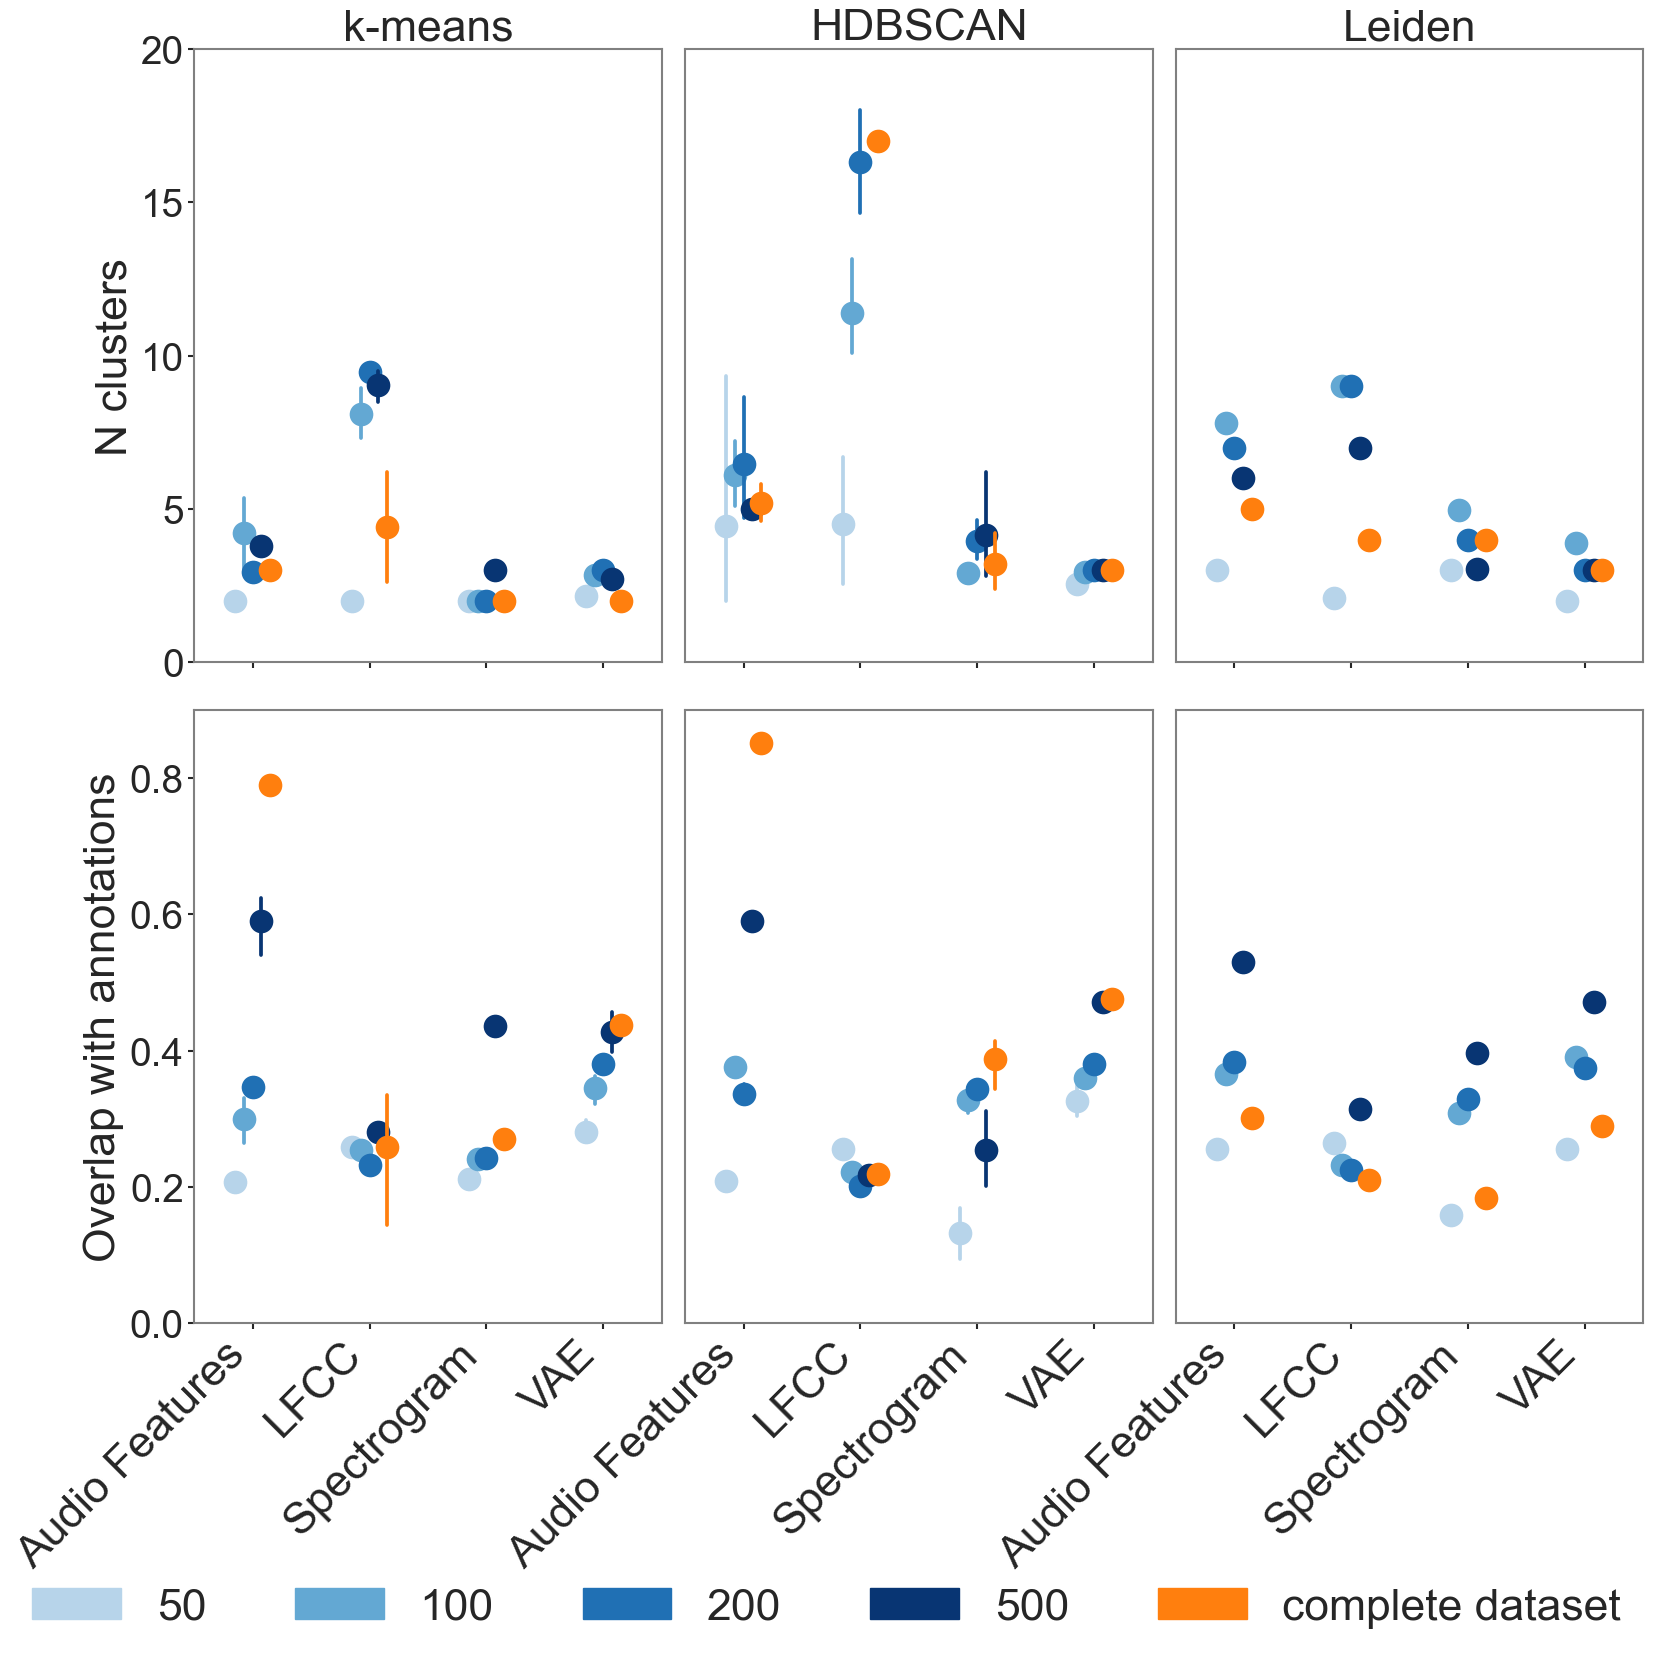

In [44]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 2)&(results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.21)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2080746171.py:54: UserWarning: set_

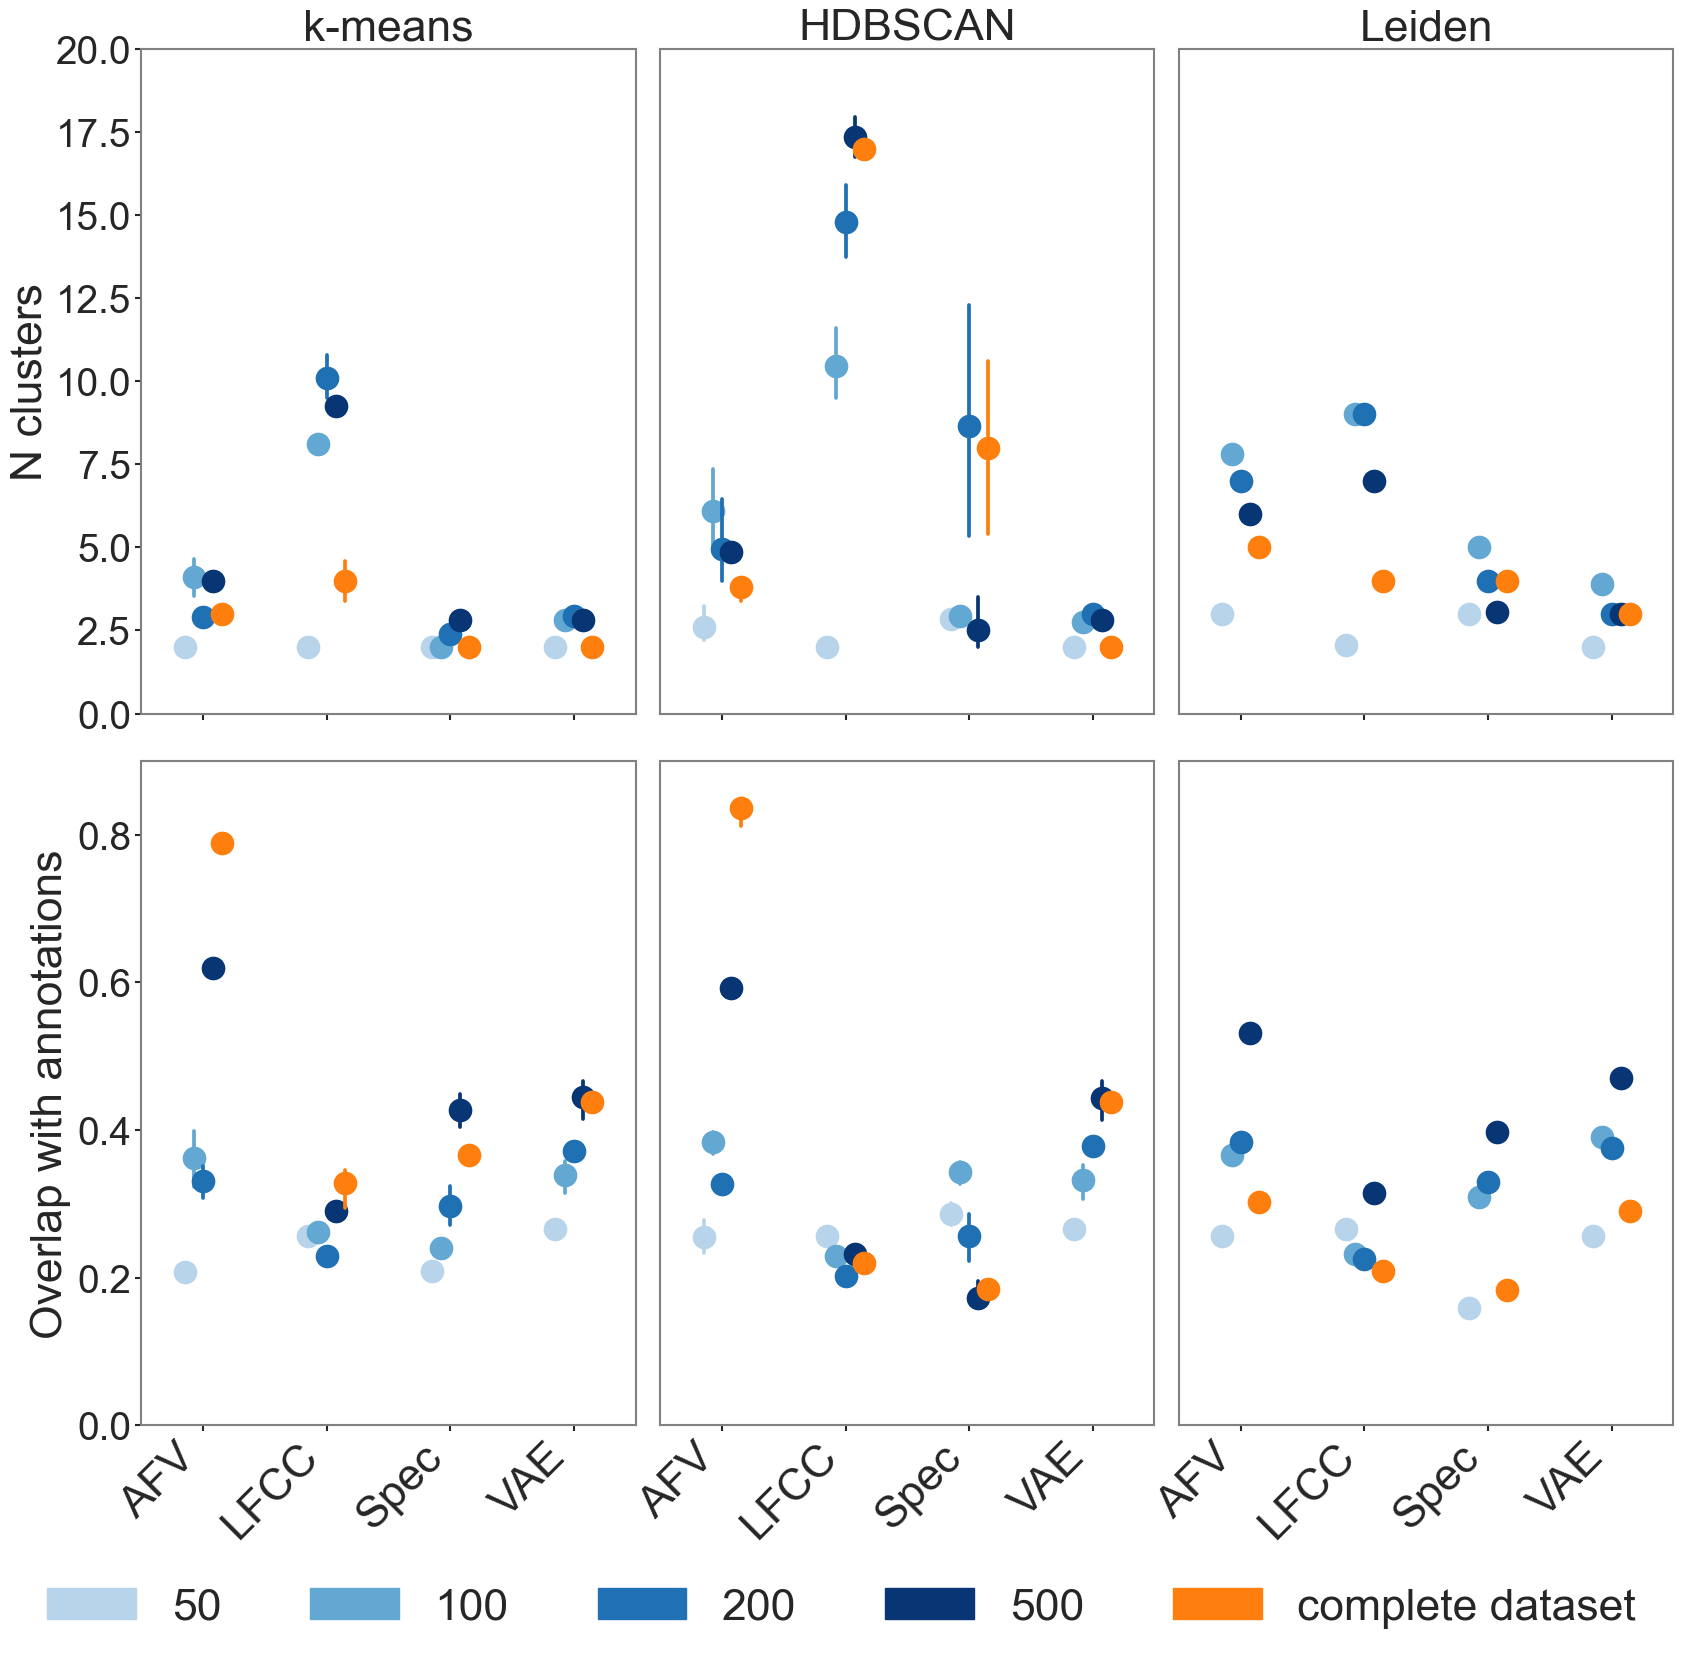

In [15]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 20) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/154244901.py:54: UserWarning: set_tick

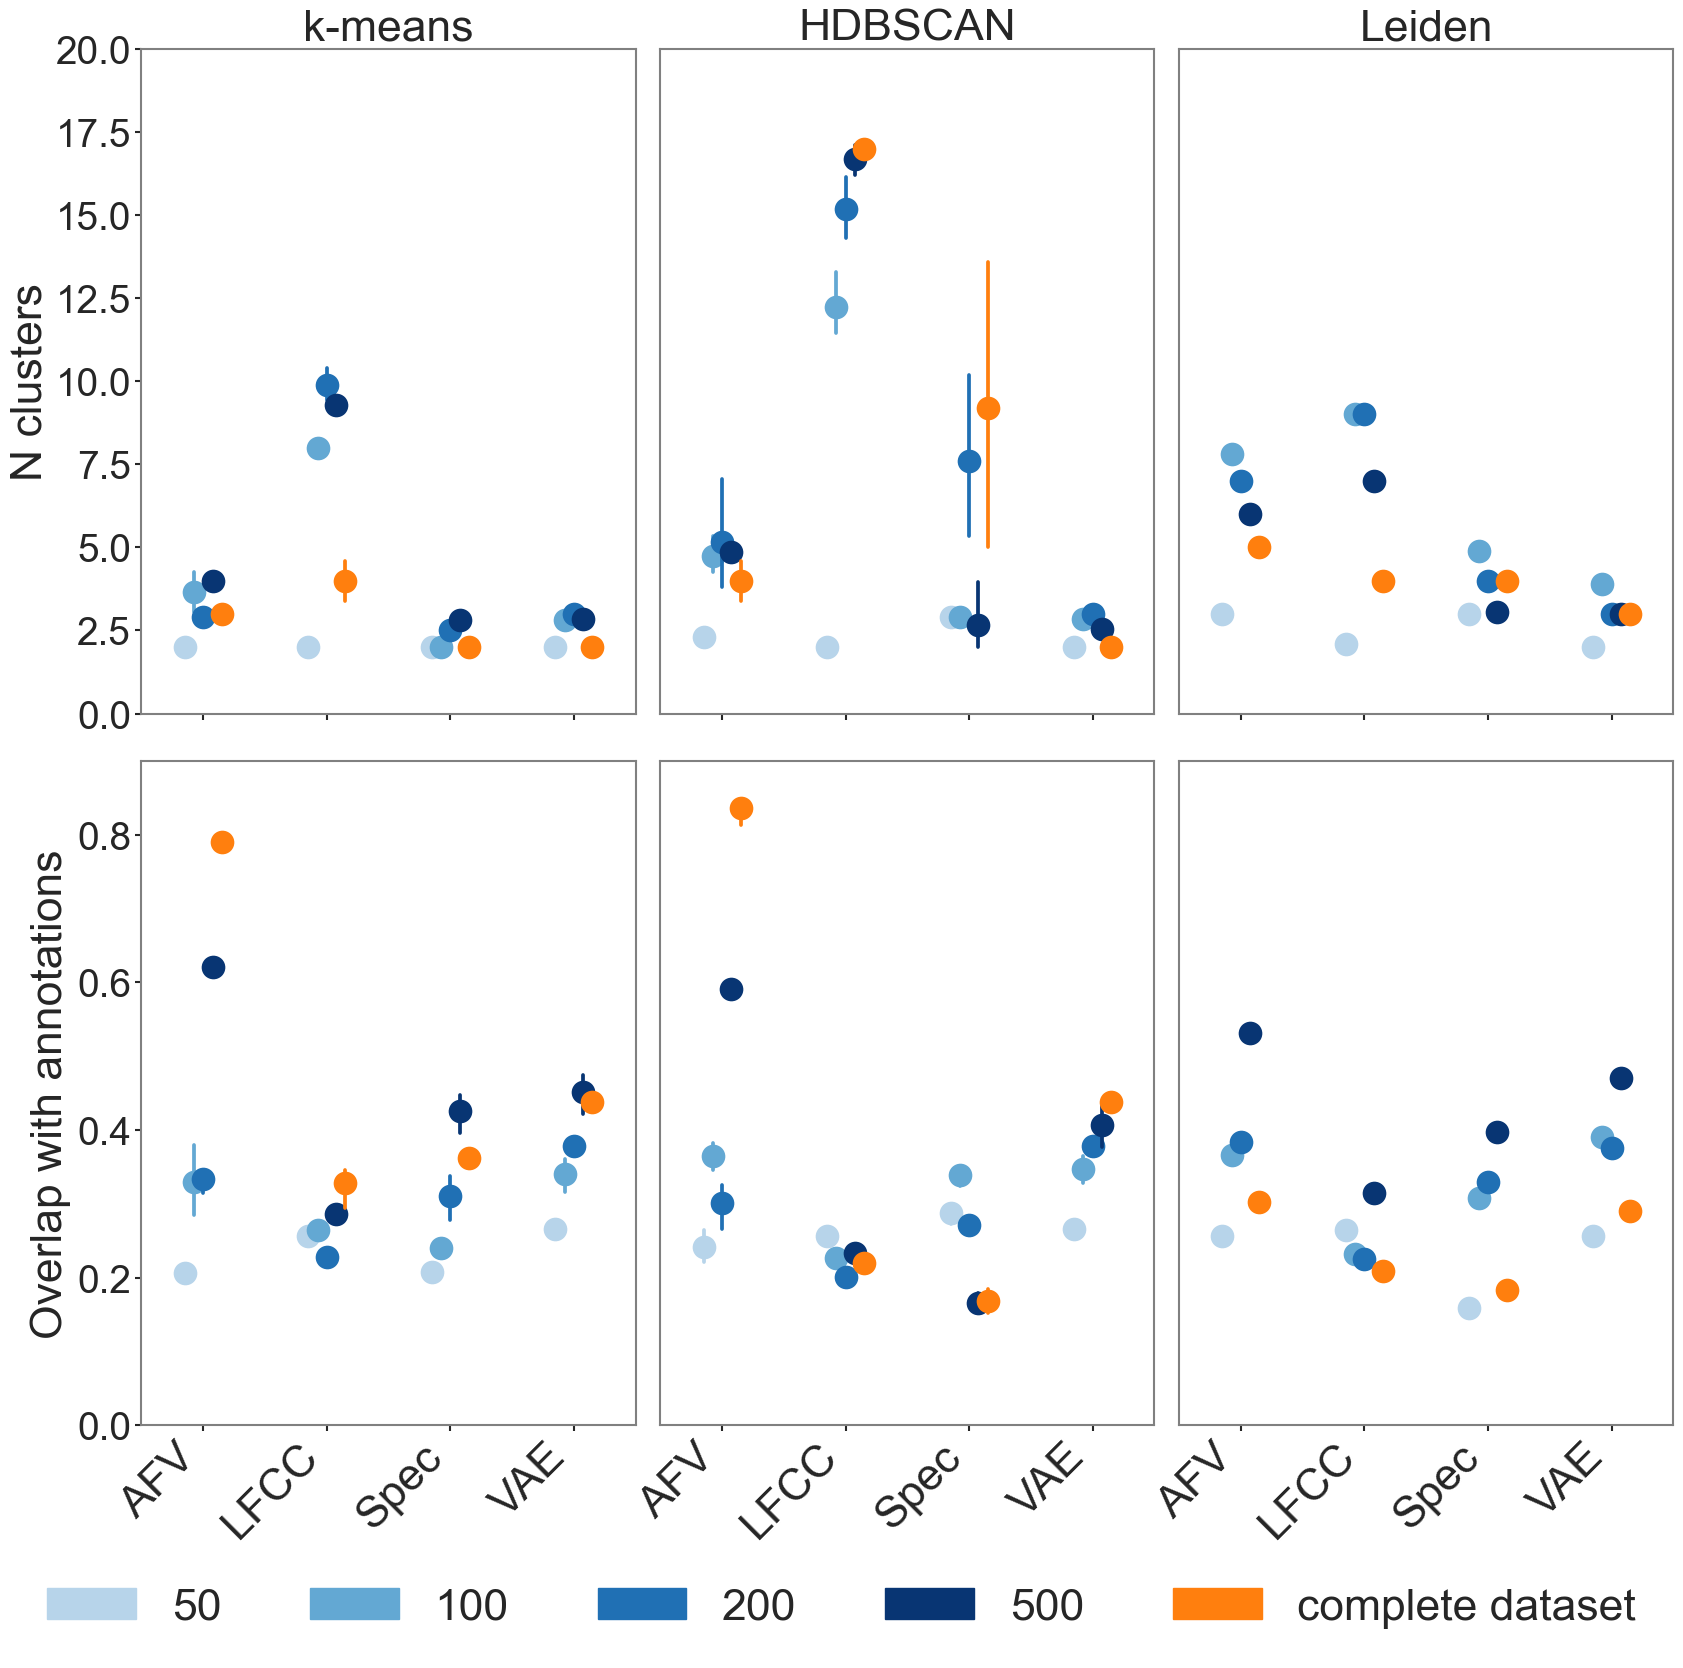

In [16]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 100) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/1841806617.

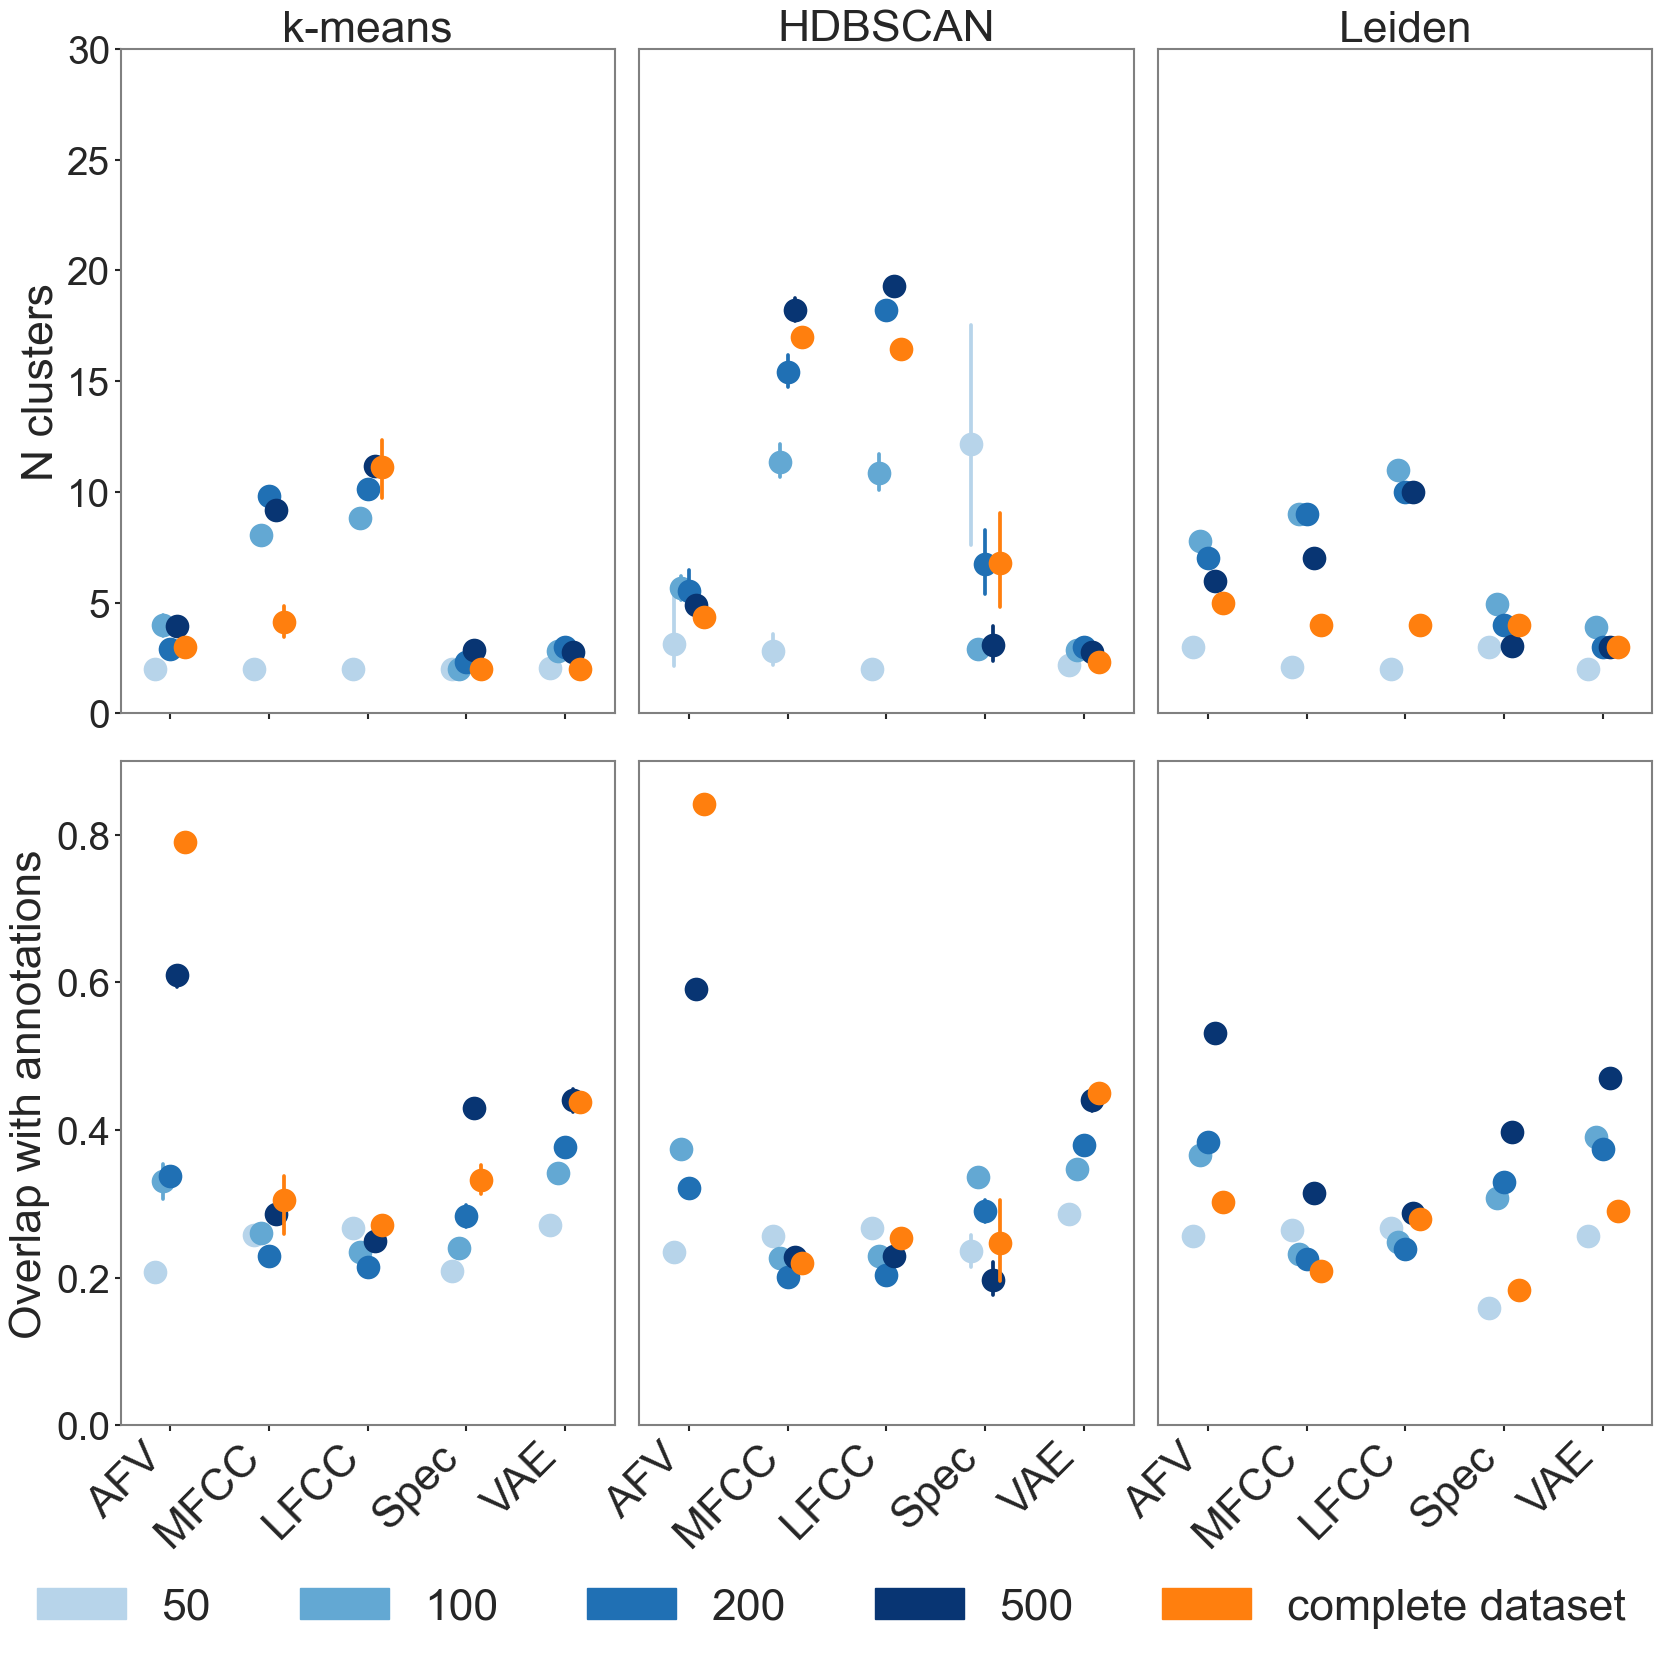

In [17]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "MFCC", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15,
            zorder=2
        )

        # sns.stripplot(
        #     x="Representation", 
        #     y=metric,  
        #     data=data, 
        #     ax=axs[row, col], 
        #     hue=hue_col,
        #     palette=palette,
        #     hue_order=hue_levels_metric,
        #     alpha=.15,
        #     dodge=.1,
        #     jitter=.7,
        #     legend=False,
        #     size=13,
        #     zorder=1
        # )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 30)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_38343/2417974276.py:74: UserWarning: set_

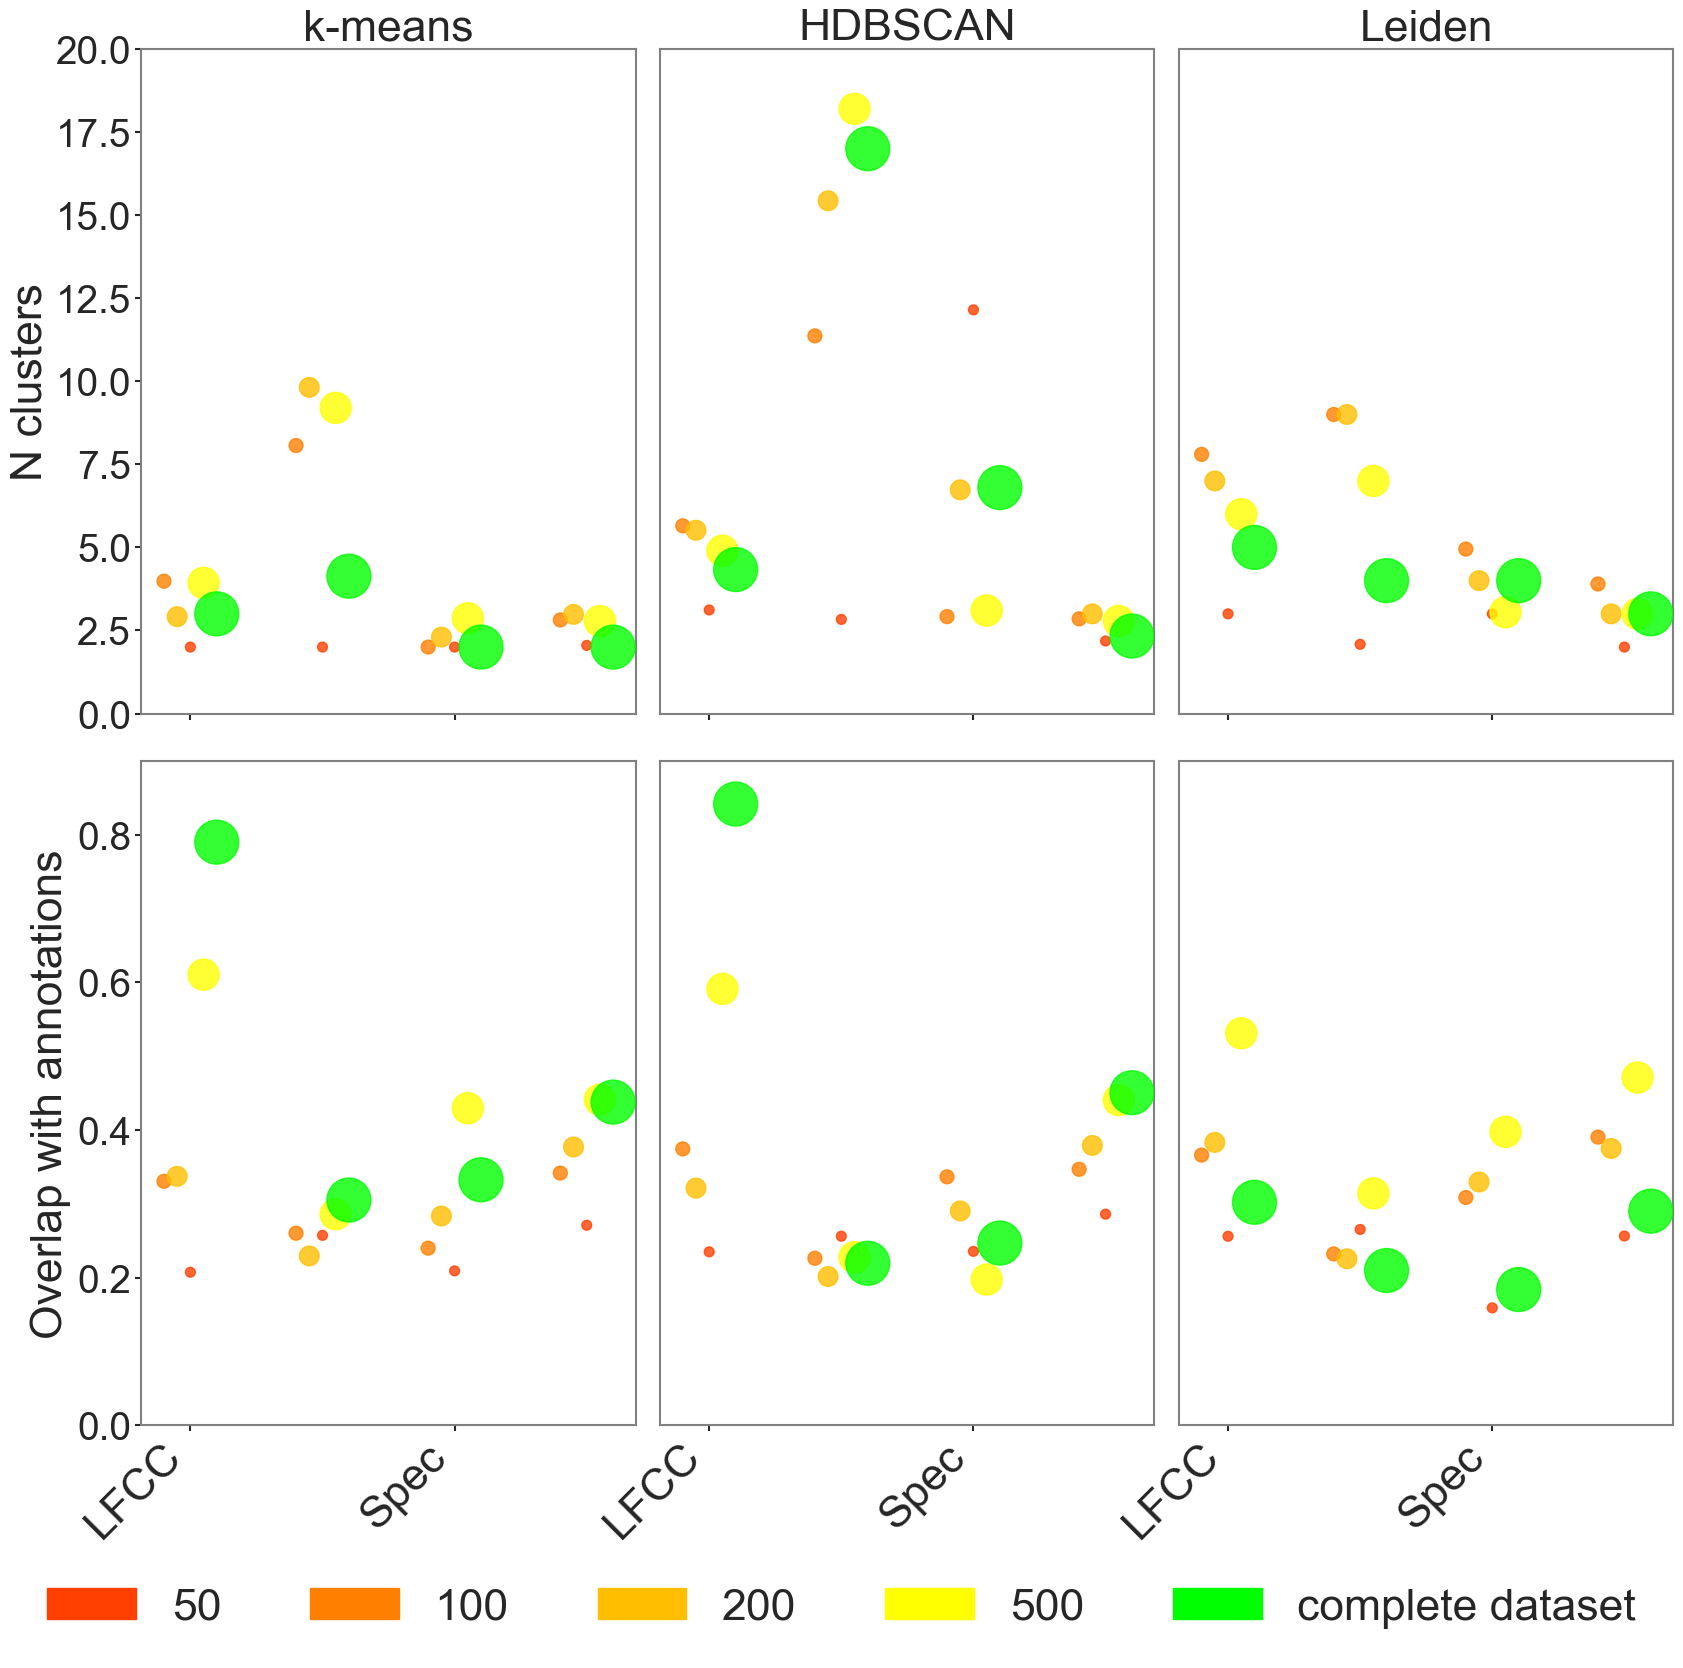

In [18]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  "#ff4000",   # darkest blue
            100: "#ff8000",
            200: "#ffbf00",
            500: "#ffff00",   # lightest blue
            "complete dataset": "#00ff00",  # tab20 orange
        }

        hue_col = "Subset size"
        size_mapping = {
            50:  50,  
            100: 100,
            200: 200,
            500: 500,  
            "complete dataset": 1000
        }

        means = pd.DataFrame(data.groupby(["Representation", "Subset size"])[metric].mean().reset_index())
        x_positions = {
            rep: i for i, rep in enumerate(means["Representation"].unique())
        }
        hue_levels = means["Subset size"].unique()
        n_hues = len(hue_levels)
        dodge_amount = 0.1

        offsets = {
            level: (i - (n_hues - 1) / 2) * dodge_amount
            for i, level in enumerate(sorted(hue_levels, key=lambda x: str(x)))
        }

        # scatter each subset size with an offset x
        for subset in hue_levels:
            sub_means = means[means["Subset size"] == subset]
            x_vals = [x_positions[r] + offsets[subset] for r in sub_means["Representation"]]
            y_vals = sub_means[metric].values

            axs[row, col].scatter(
                x_vals,
                y_vals,
                s=[size_mapping[subset]] * len(x_vals),
                color=palette[subset],
                label=subset,
                alpha=0.8,
                zorder=3,
            )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


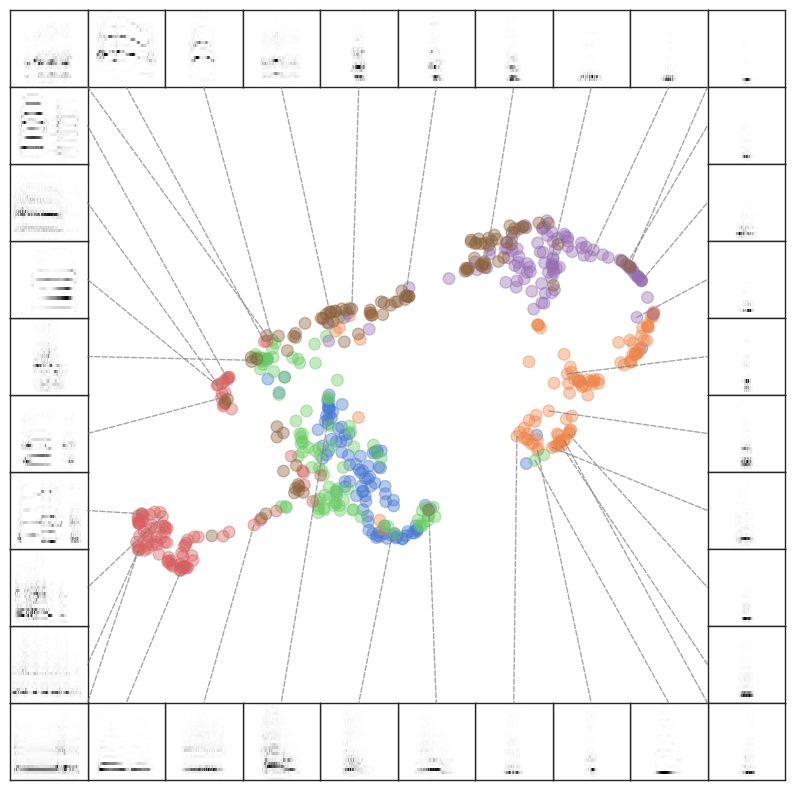

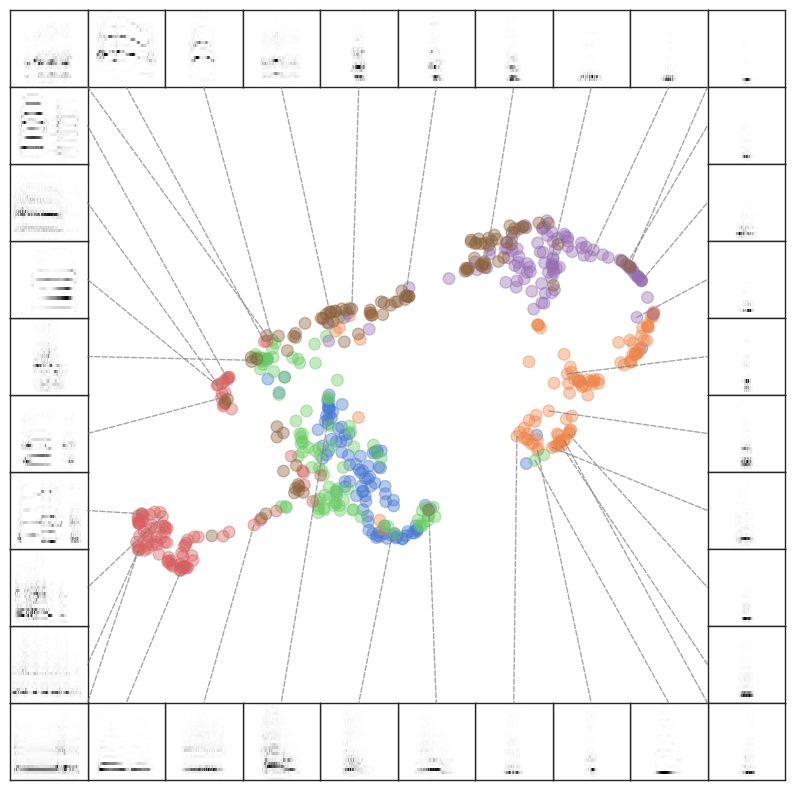

In [19]:
vis_data_sub = vis_data[0]
scatter_spec(
    vis_data_sub["embeddings"]["paf"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"],
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


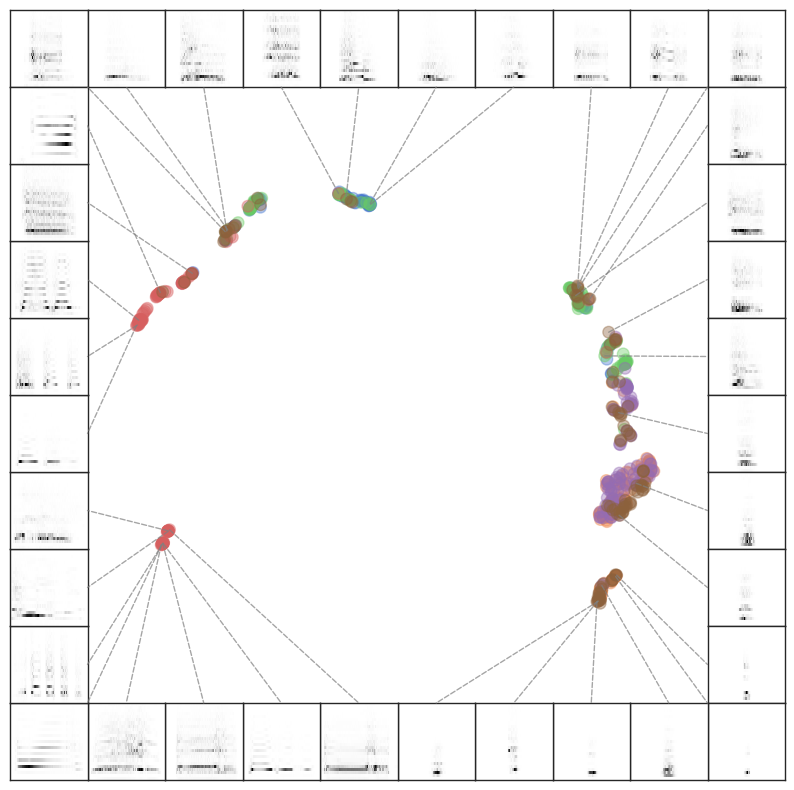

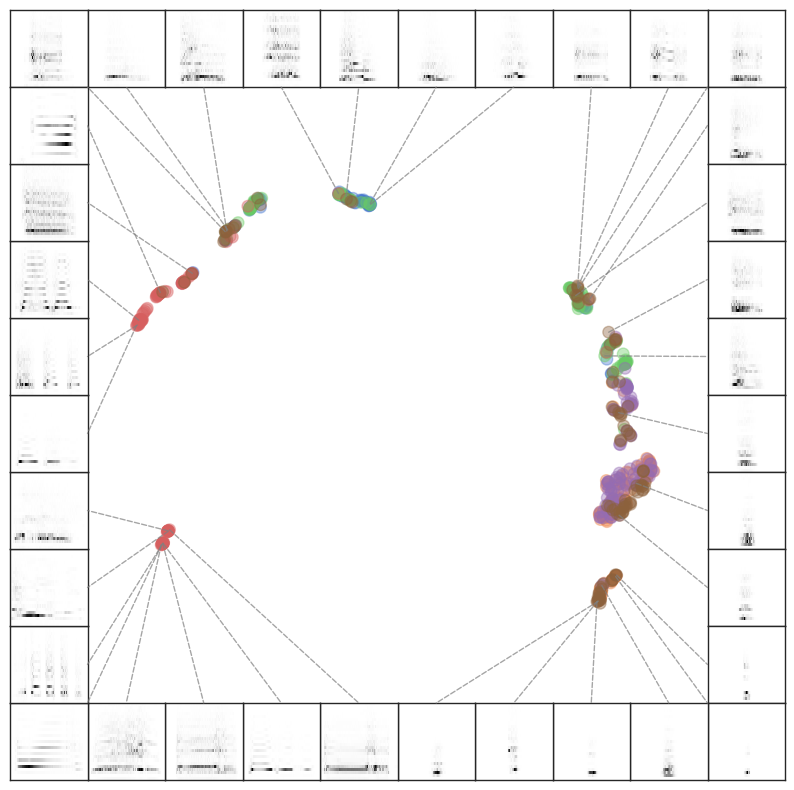

In [20]:
scatter_spec(
    vis_data_sub["embeddings"]["lfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


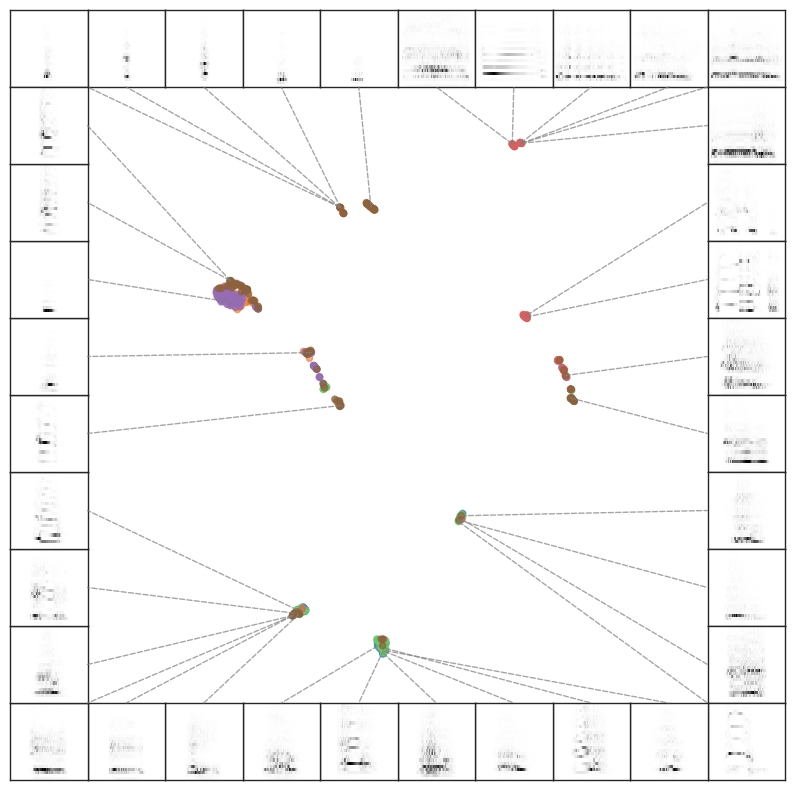

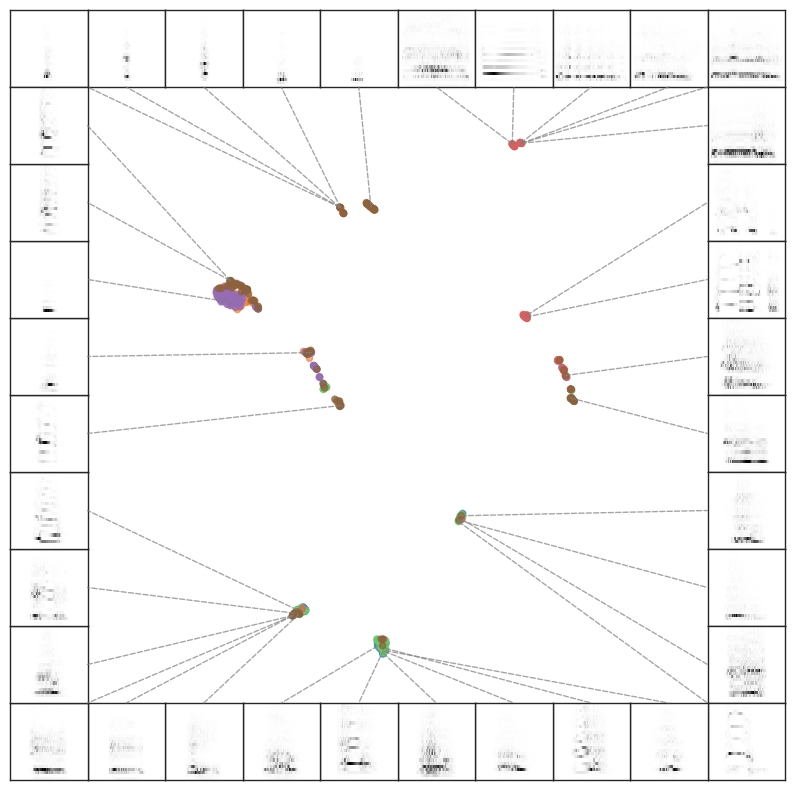

In [21]:
scatter_spec(
    vis_data_sub["embeddings"]["mfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.7, "s": 20, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


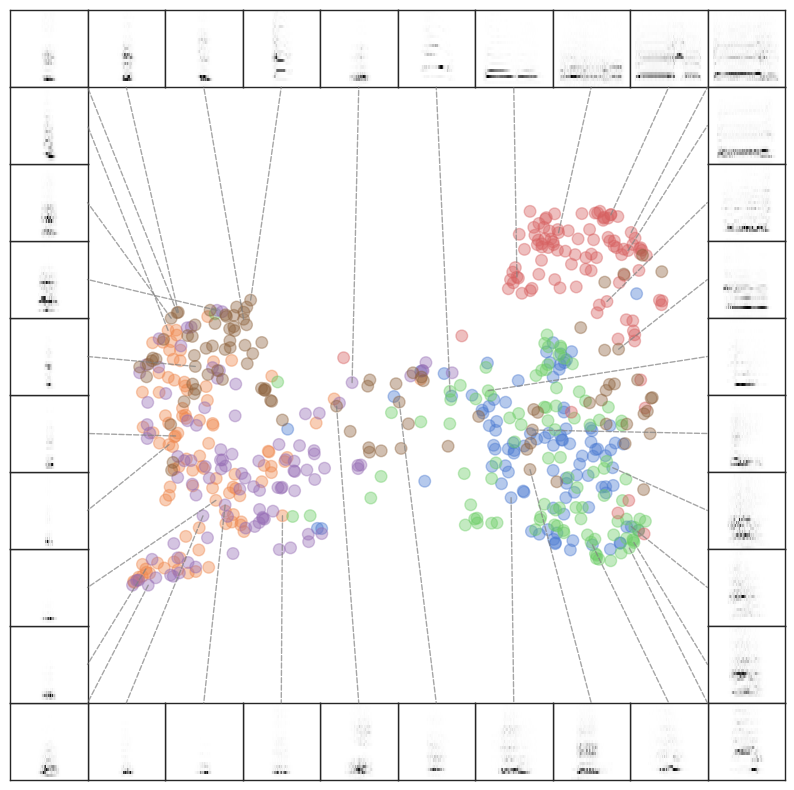

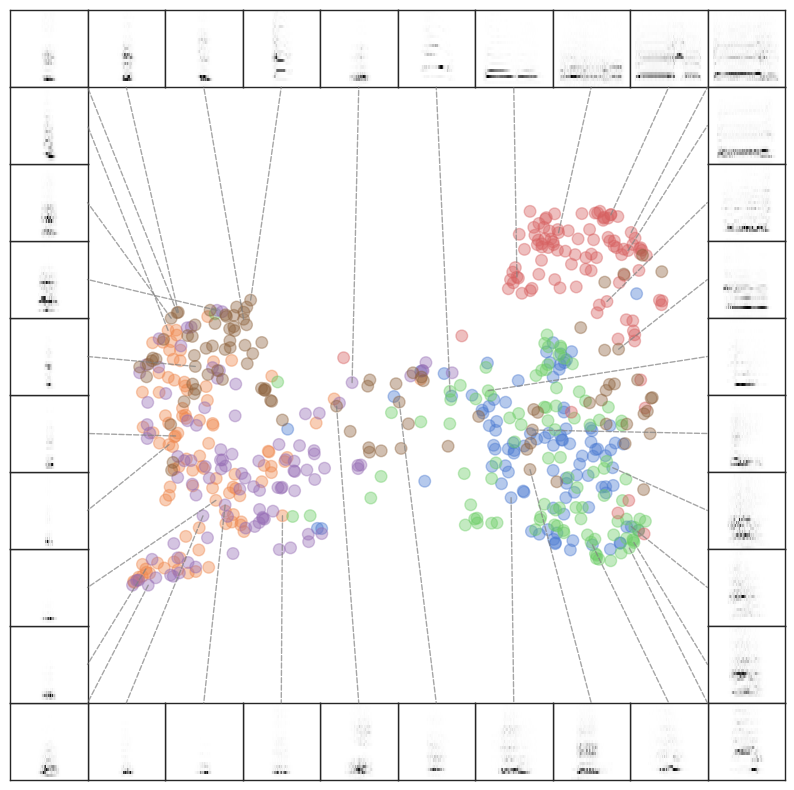

In [22]:
scatter_spec(
    vis_data_sub["embeddings"]["spec"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


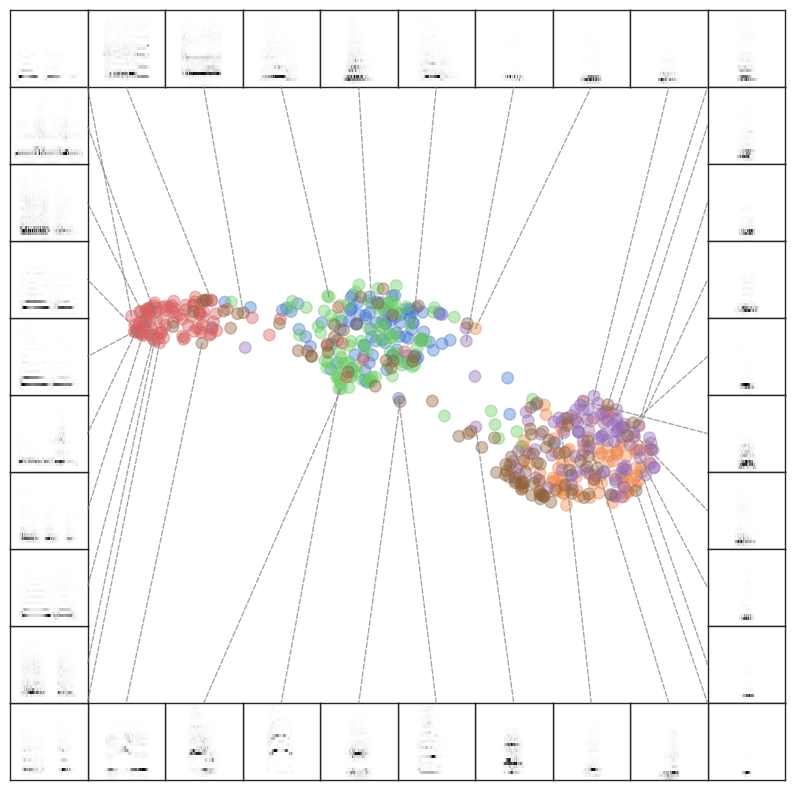

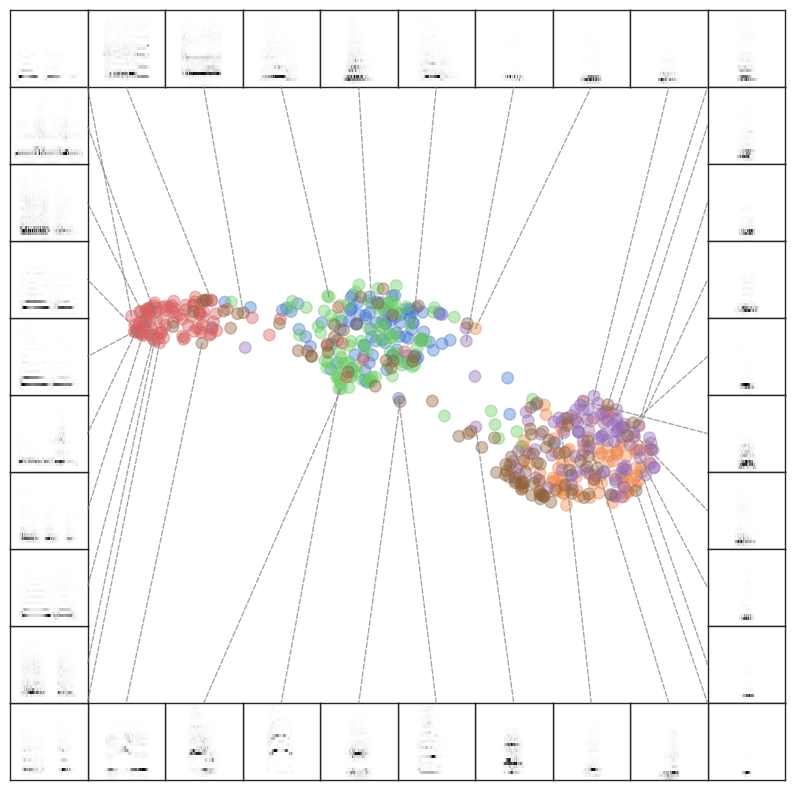

In [23]:
scatter_spec(
    vis_data_sub["embeddings"]["vae"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

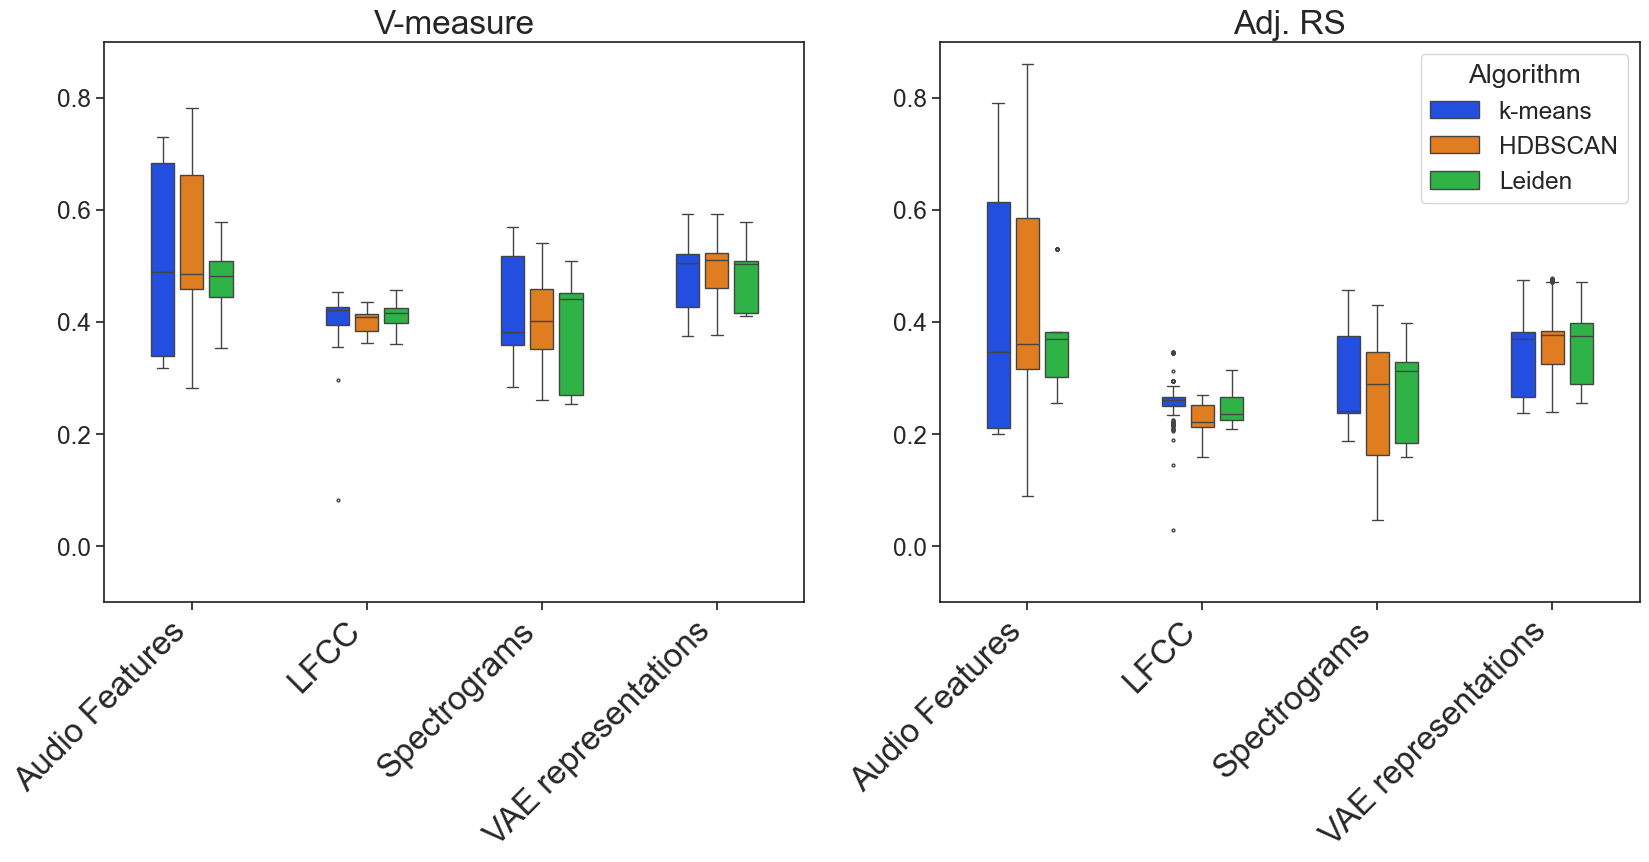

In [24]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.boxplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        gap=.2,
        fliersize=2,
        width=.5,
        palette="bright"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


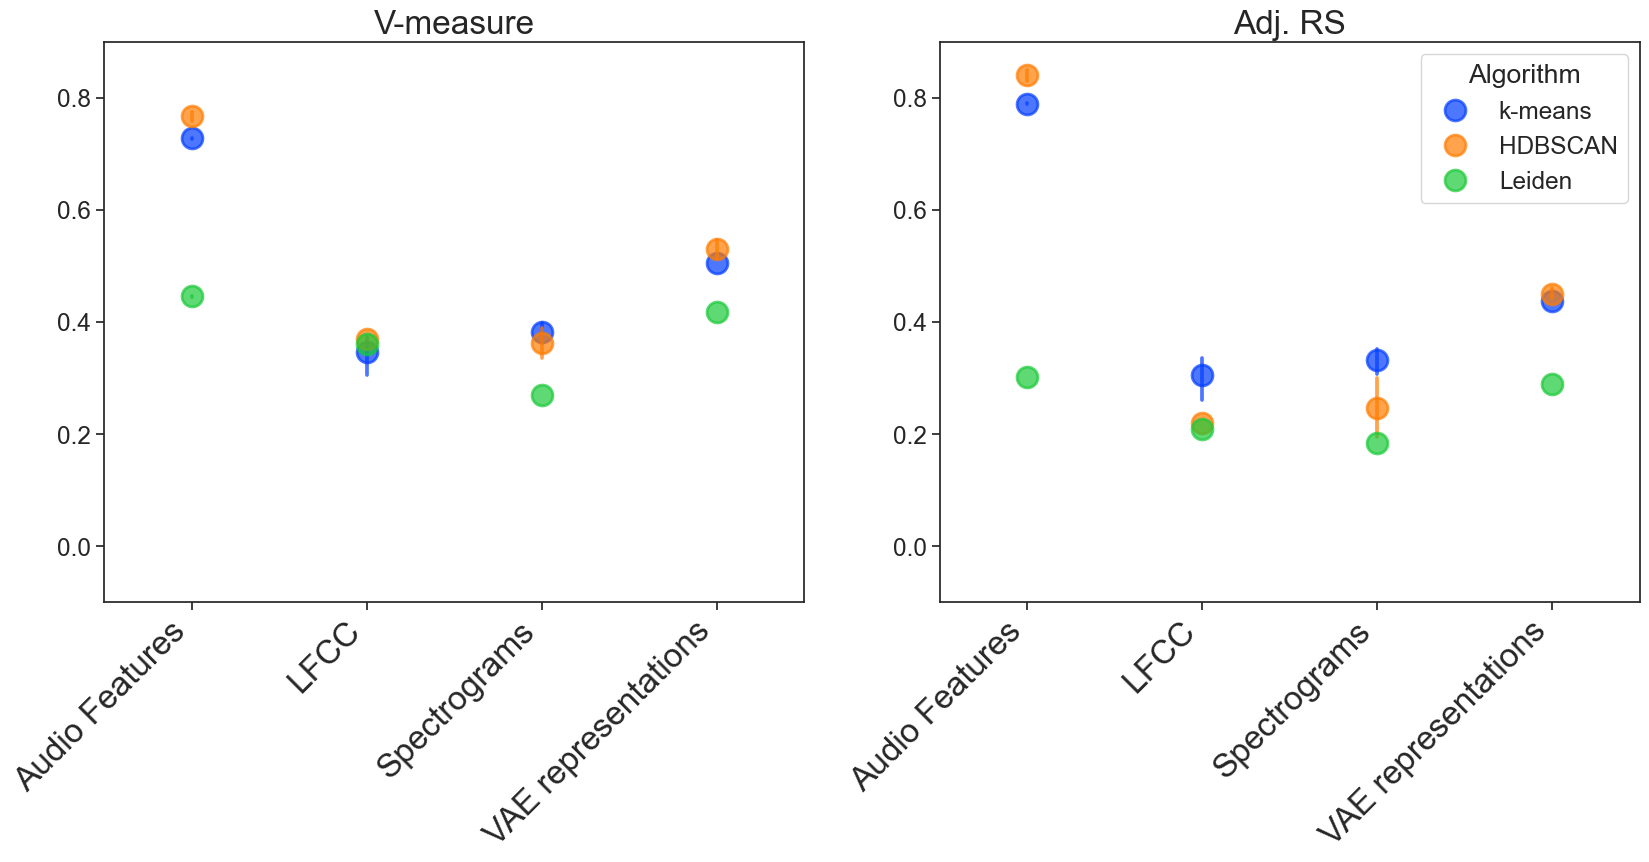

In [25]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']=="complete dataset")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


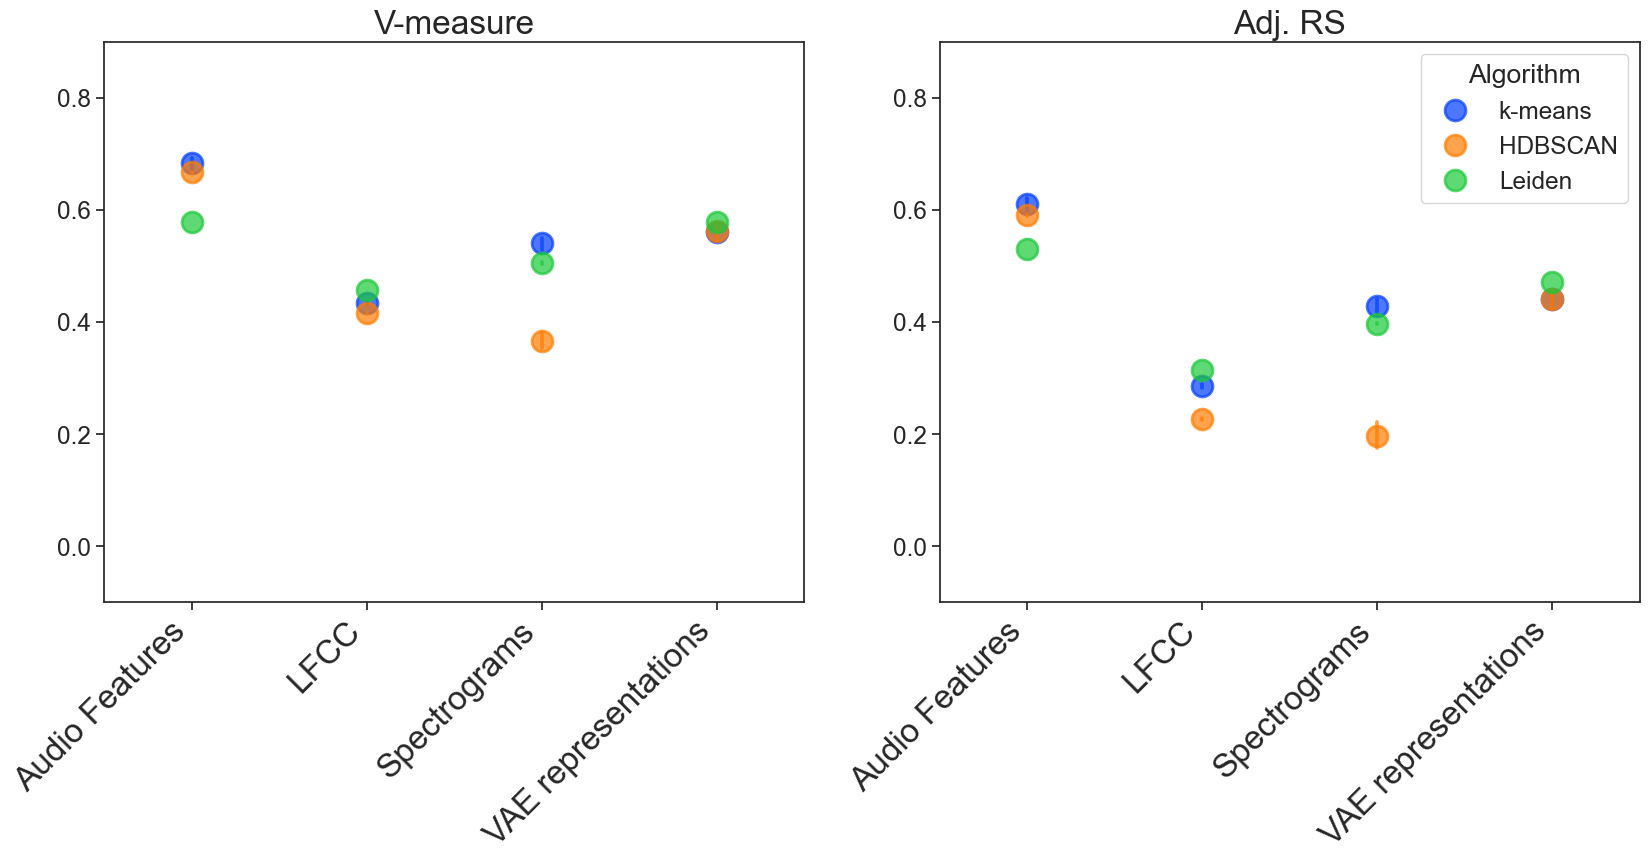

In [26]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']==500)], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


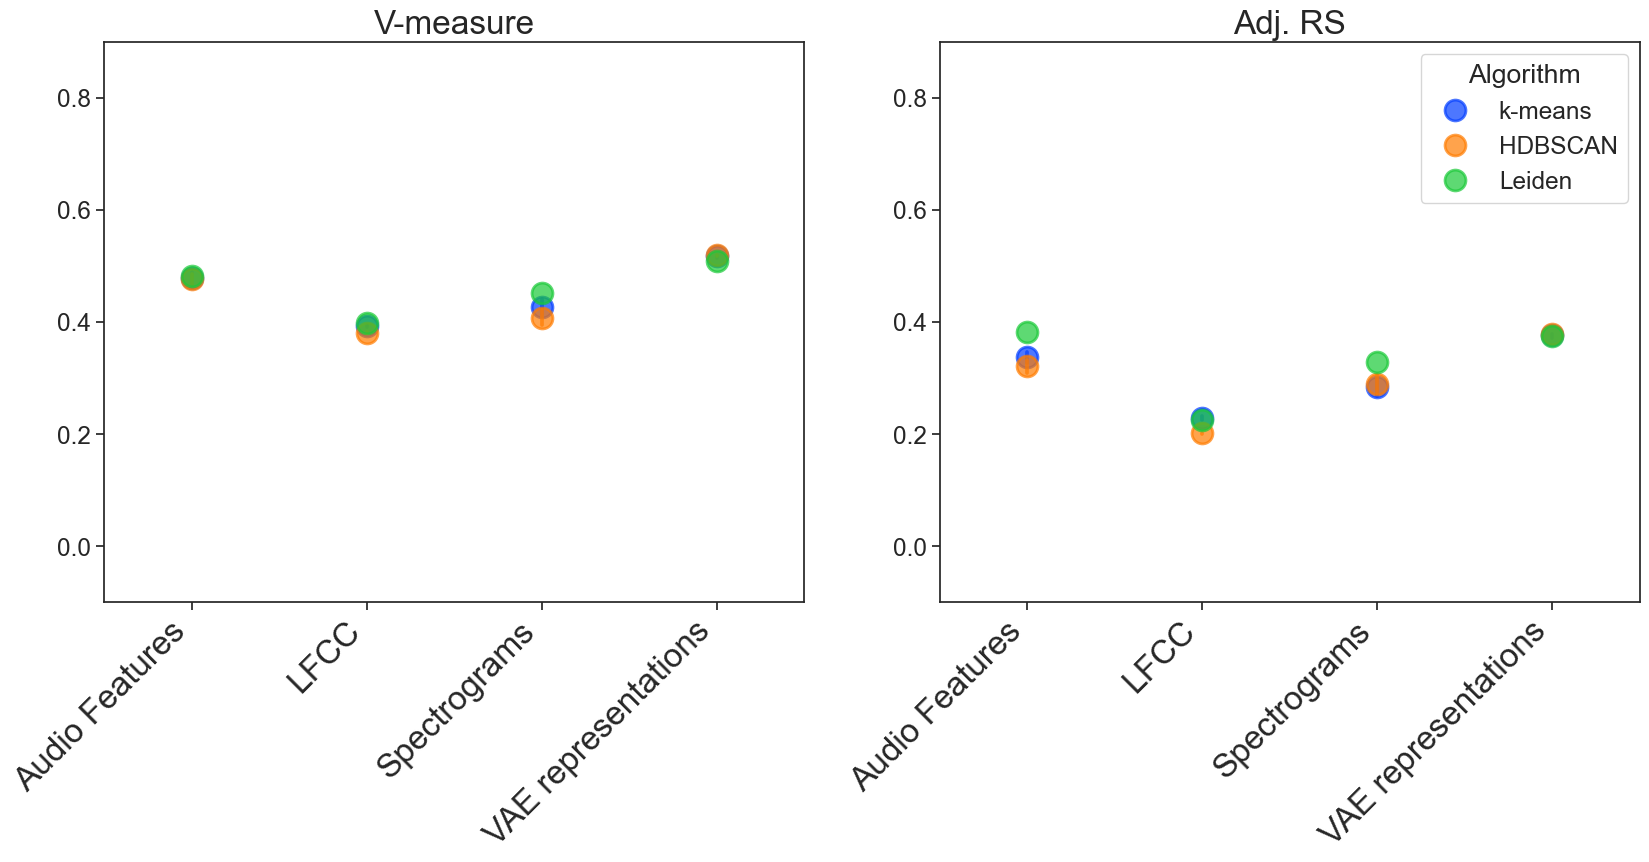

In [27]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']==200)], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


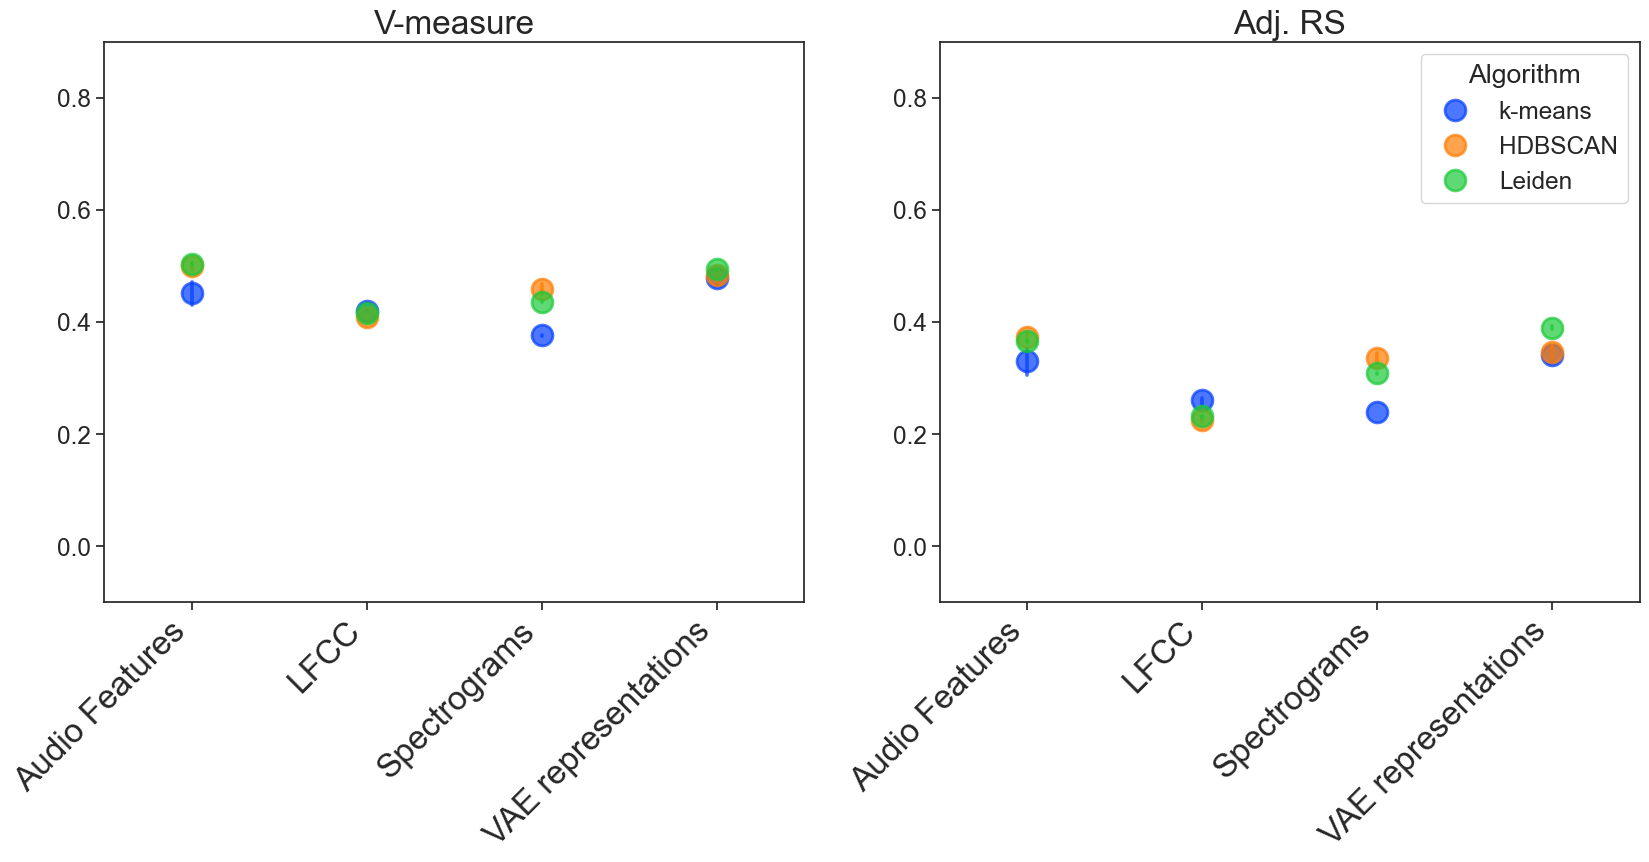

In [28]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']==100)], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


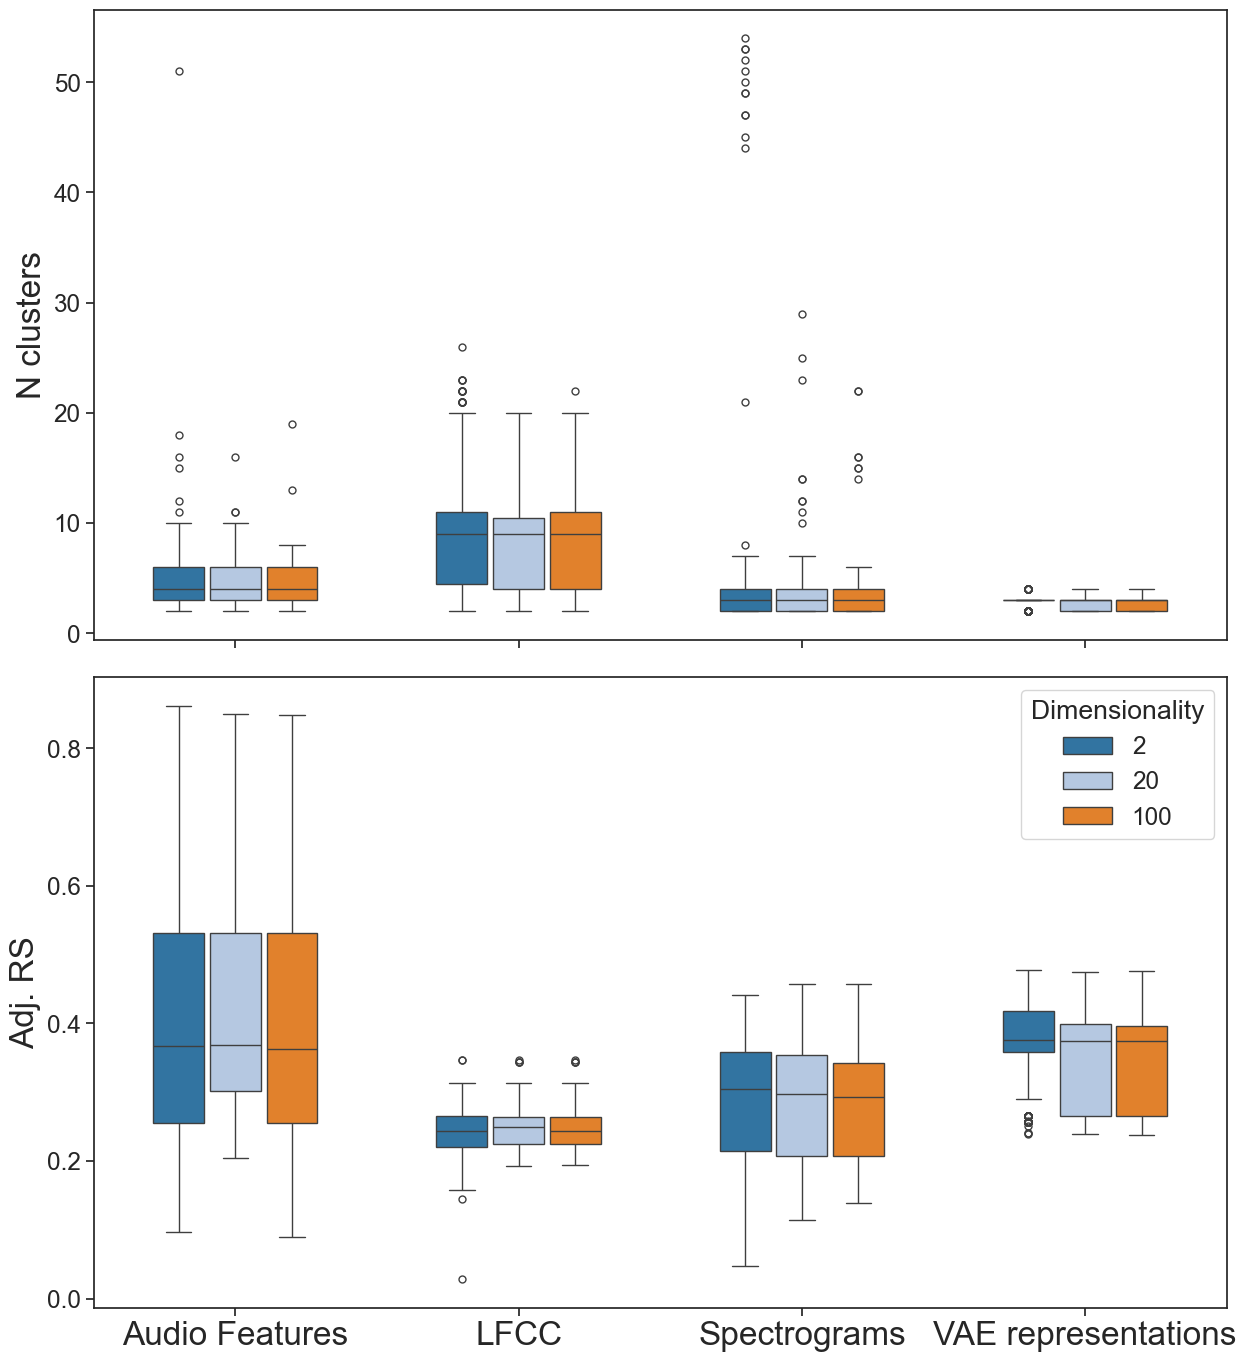

In [29]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Dimensionality", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


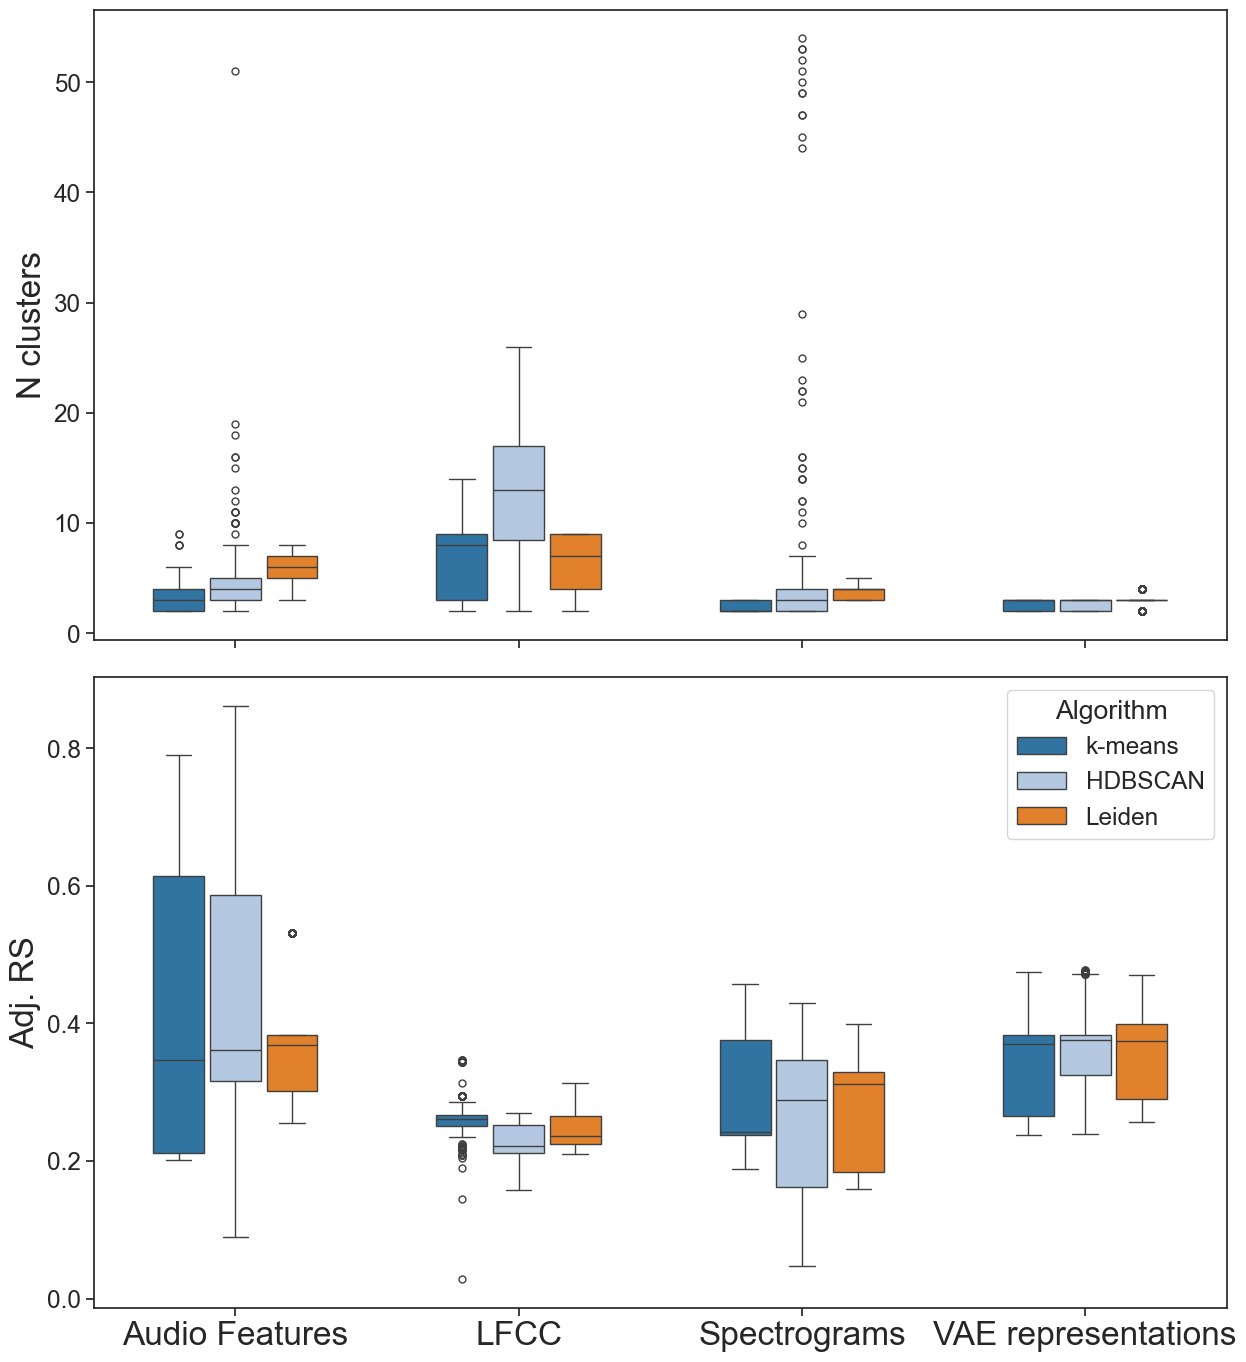

In [30]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


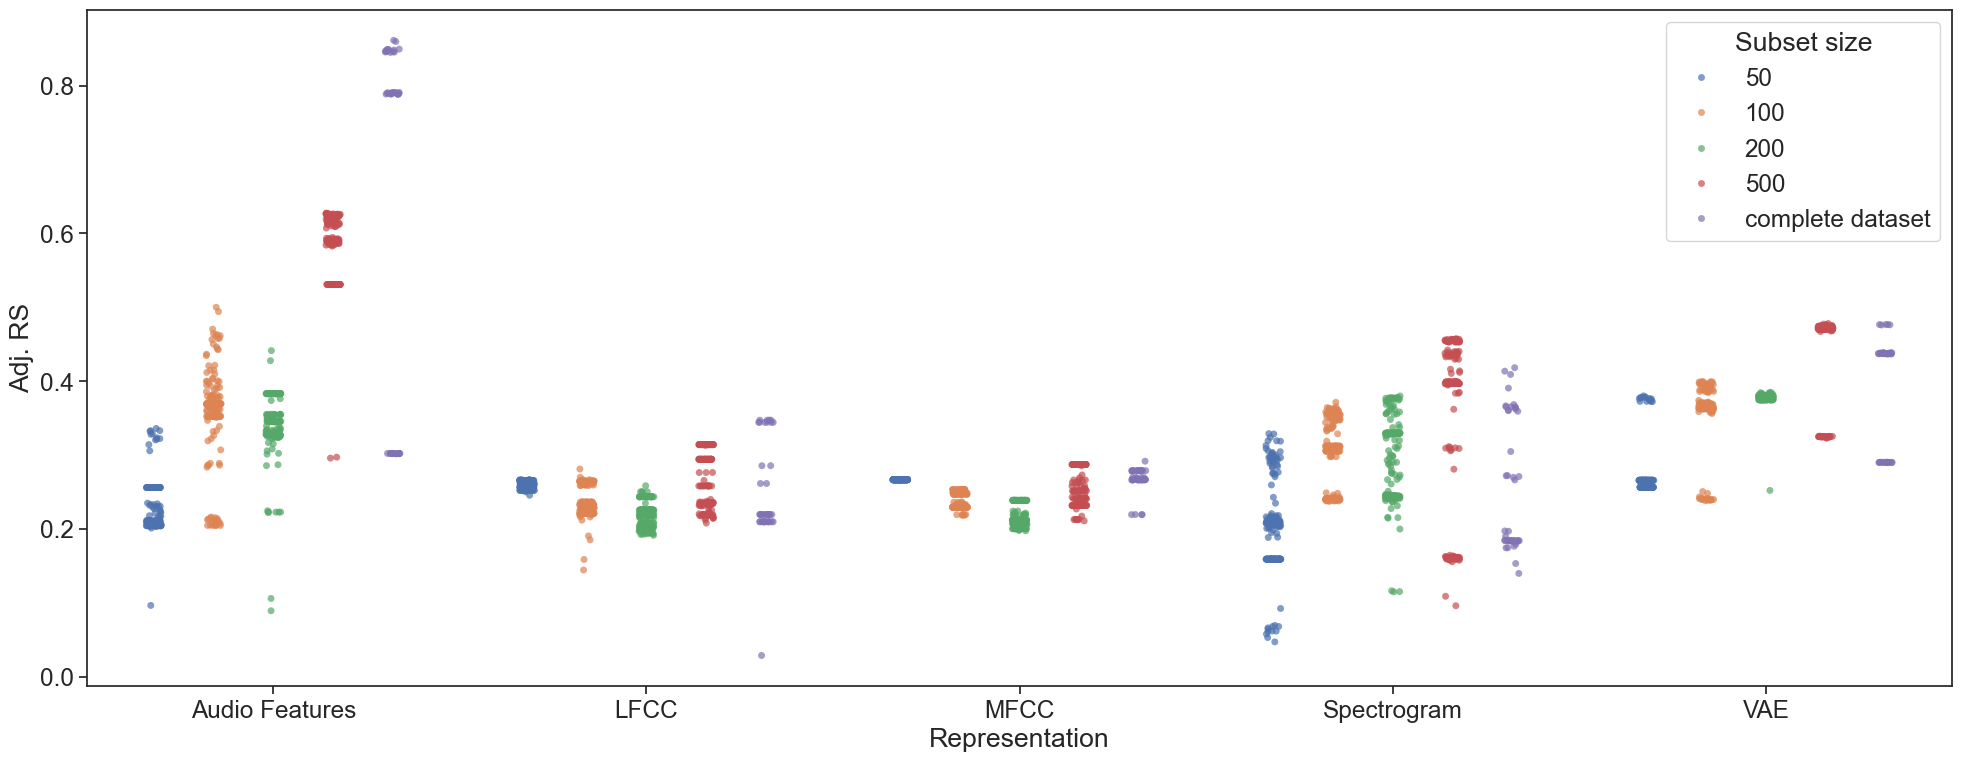

In [31]:
rows = ["Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Representation", 
    y="Adj. RS",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

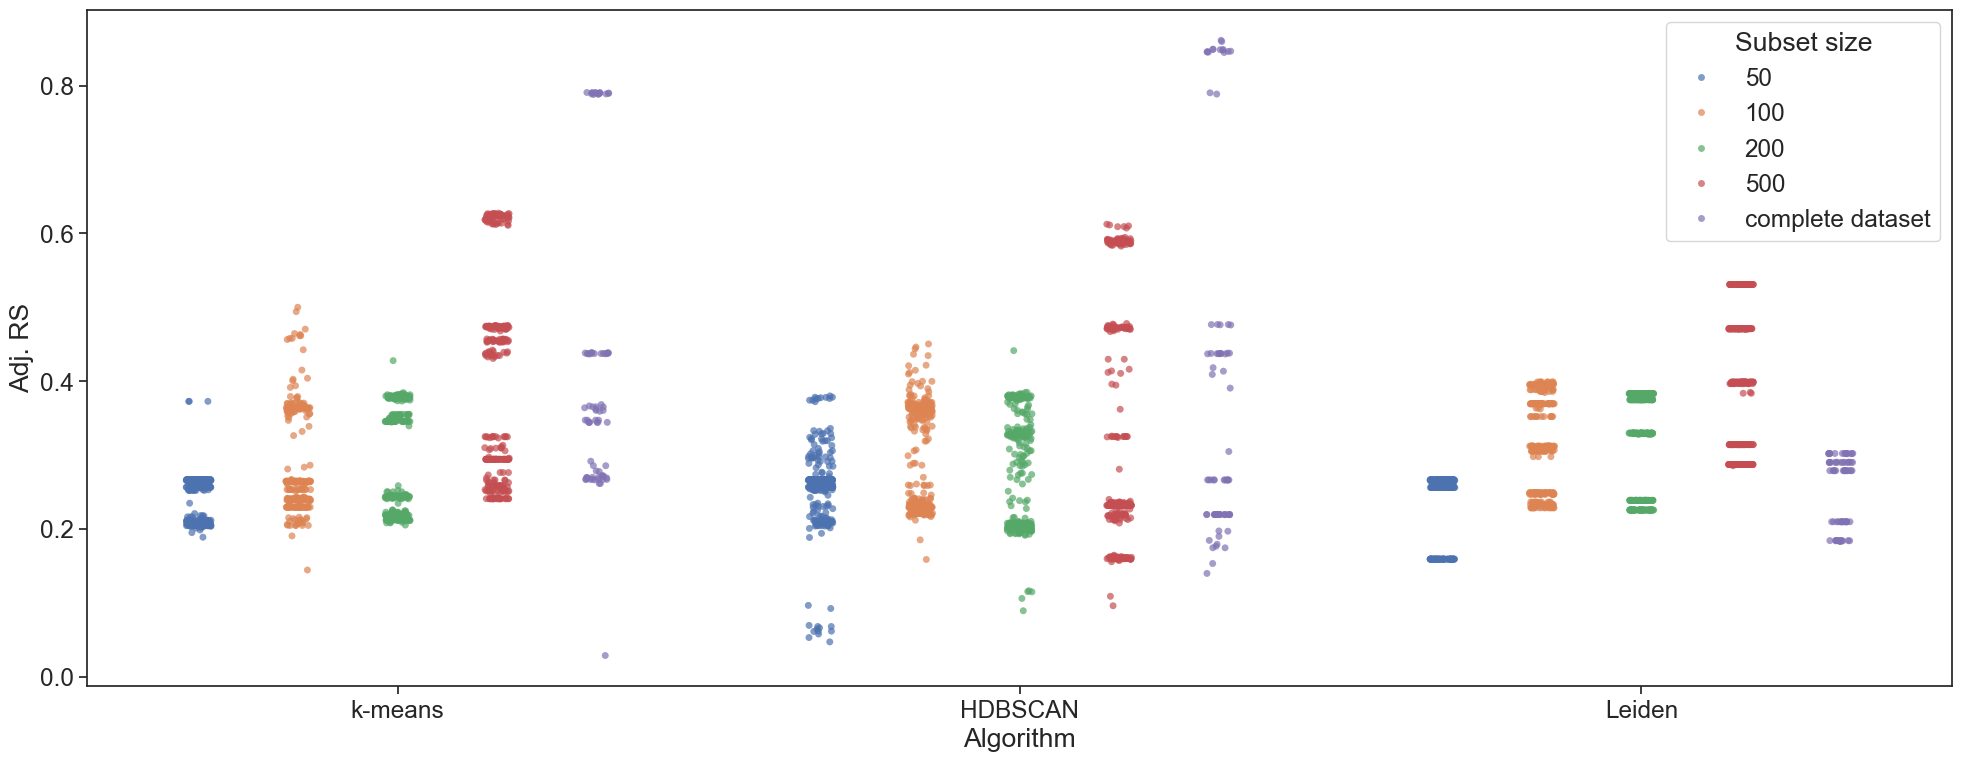

In [32]:
rows = ["Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Algorithm", 
    y="Adj. RS",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

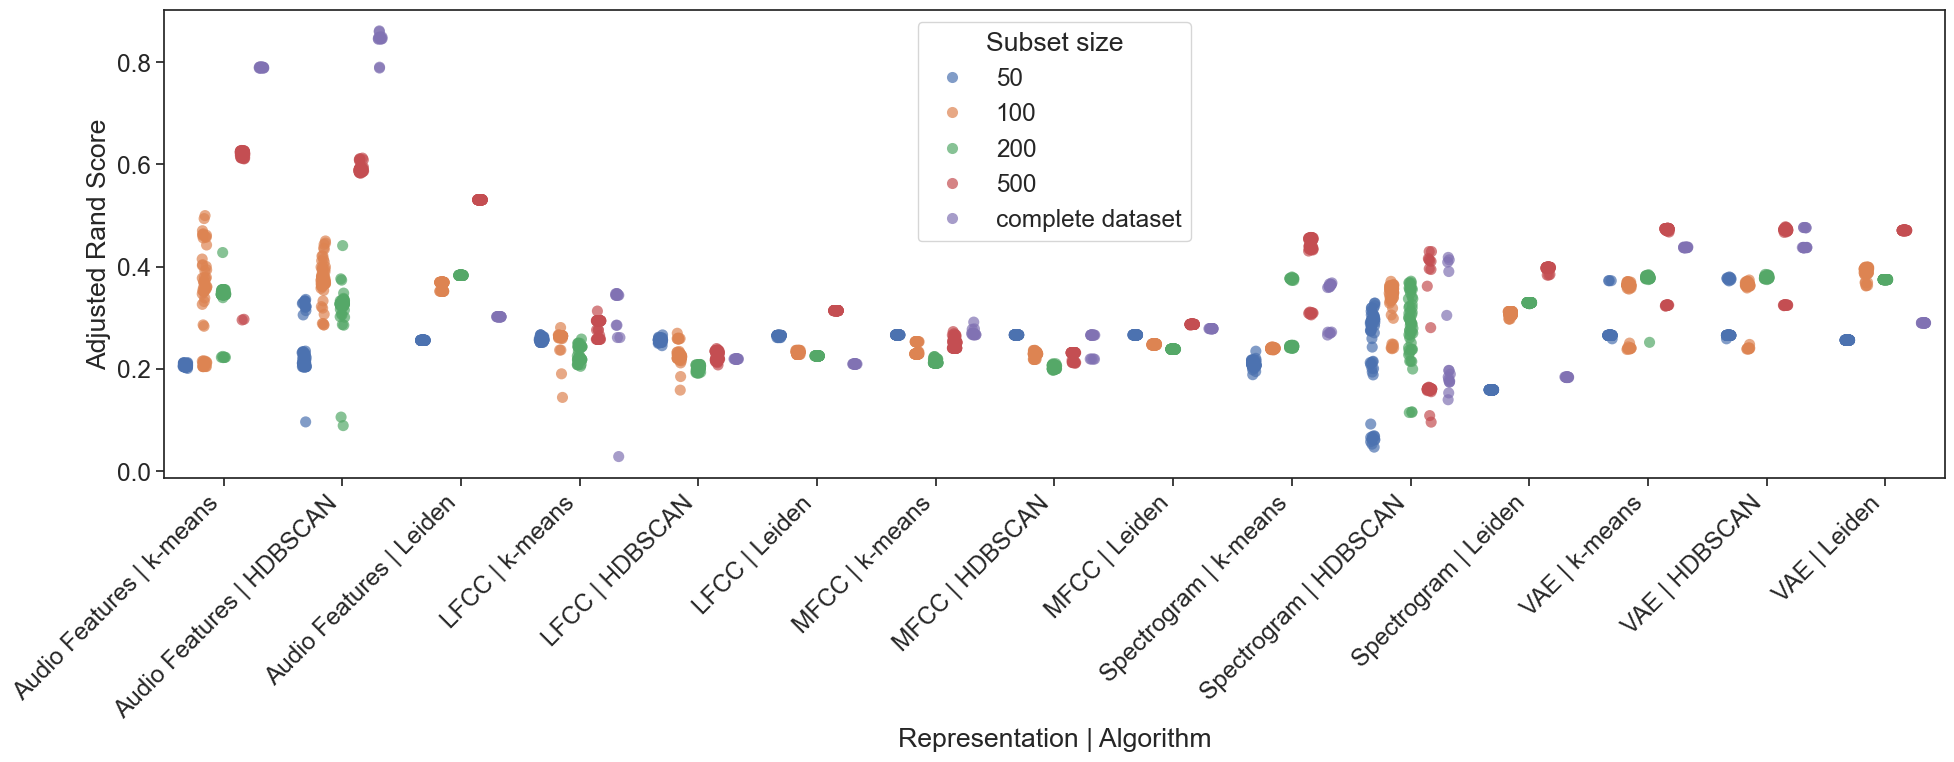

In [33]:
rows: list[str] = ["Adj. RS"]
columns: list[str] = ["k-means", "HDBSCAN", "Leiden"]
representations: list[str] = ["PAF", "LFCC", "Spectrogram", "VAE"]
sub_df = results_df.copy()
sub_df["Rep_Algo"] = sub_df["Representation"] + " | " + sub_df["Algorithm"]


fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Rep_Algo", 
    y="Adj. RS",  
    data=sub_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=0.0001,
    legend=True,
    size=8,
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Representation | Algorithm")
plt.ylabel("Adjusted Rand Score")

plt.tight_layout()
plt.show()

# Raw numbers

In [34]:
sub_df = results_df[(results_df['Dimensionality']==20)]

In [35]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].min())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].max())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].mean())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].std())

Audio Features
2
16
4.568627450980392
2.1171859755696922
LFCC
2
20
8.419607843137255
4.850562902955573
Spectrogram
2
29
3.5058823529411764
2.997204193616221
VAE
2
4
2.7254901960784315
0.5845258988944013


In [36]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
16
4.694117647058824
3.356293473811988
  Audio Features
6
2
3.235294117647059
1.0538710821078077
  LFCC
13
2
7.1647058823529415
3.305288182895524
  Spectrogram
3
2
2.2823529411764705
0.45281565433046
  VAE
3
2
2.6
0.4928053803045811
HDBSCAN
2
29
7.129411764705883
6.270980324369935
  Audio Features
16
2
4.576470588235294
2.3723429778347382
  LFCC
20
2
11.494117647058824
6.130764594225089
  Spectrogram
29
2
4.458823529411765
4.878409530966084
  VAE
3
2
2.6
0.4928053803045811
Leiden
2
11
5.449411764705882
2.924829600318453
  Audio Features
8
3
5.894117647058824
1.7996264785184939
  LFCC
9
2
6.6
2.850229731760148
  Spectrogram
5
3
3.776470588235294
0.8073541529535329
  VAE
4
2
2.976470588235294
0.6721761140440177


In [37]:
sub_df = results_df

for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
16
4.6776470588235295
3.3709108539421297
  Audio Features
9
2
3.196078431372549
1.239437385749833
  LFCC
14
2
7.086274509803921
3.245895021604492
  Spectrogram
3
2
2.2745098039215685
0.44714454375933177
  VAE
3
2
2.619607843137255
0.4864379640320324
HDBSCAN
2
54
7.7552941176470584
7.686031477824241
  Audio Features
51
2
4.768627450980392
3.8919202695177164
  LFCC
26
2
12.254901960784315
6.3489199814846735
  Spectrogram
54
2
6.258823529411765
10.412159315079355
  VAE
3
2
2.6823529411764704
0.4664769459296302
Leiden
2
11
5.448627450980392
2.9217133714908656
  Audio Features
8
3
5.894117647058824
1.7925273325874789
  LFCC
9
2
6.607843137254902
2.8275809154761467
  Spectrogram
5
3
3.764705882352941
0.7933839439045742
  VAE
4
2
2.976470588235294
0.6695245214041556


In [38]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].mean())
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].std())

Audio Features
0.4986704967038842
0.12126869605136897
  k-means
   0.5015926844834537
   0.1440162271372376
  HDBSCAN
   0.5165754560092024
   0.12827695315800258
  Leiden
   0.4778433496189963
   0.07919933861237025
LFCC
0.4116872471890666
0.025614416925409198
  k-means
   0.41169487147766975
   0.029438724721491793
  HDBSCAN
   0.4032519986502372
   0.017377812927109864
  Leiden
   0.4201148714392927
   0.025731230304203868
Spectrogram
0.40819974308683254
0.08243911117025027
  k-means
   0.4169789060945906
   0.08472031472337282
  HDBSCAN
   0.4039026218721156
   0.05909379181735441
  Leiden
   0.4037177012937916
   0.09826720589963728
VAE
0.49836245067415424
0.05991218649361823
  k-means
   0.4976831314935079
   0.05970035319046181
  HDBSCAN
   0.5041157141000508
   0.05831085857685963
  Leiden
   0.4932885064289038
   0.06142349307601156


In [39]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].std())

Audio Features
0.3941370022999328
0.15579820872780195
  k-means
   0.395863931920277
   0.18336838550460086
  HDBSCAN
   0.4074321723915812
   0.17188241419920539
  Leiden
   0.37911490258794045
   0.09713825013003806
LFCC
0.2481291786941137
0.034057174731840605
  k-means
   0.260867249729986
   0.03275232833456728
  HDBSCAN
   0.2272830742793487
   0.021214005031586377
  Leiden
   0.25623721207300637
   0.03606785556873352
Spectrogram
0.2828204226134871
0.09170356636151787
  k-means
   0.2928663003264243
   0.0915560589886847
  HDBSCAN
   0.2638036846422958
   0.09204692610820588
  Leiden
   0.29179128287174116
   0.08885116966555244
VAE
0.36617565091517634
0.07448520188073693
  k-means
   0.36226983583114514
   0.07443695208147205
  HDBSCAN
   0.36807266423235585
   0.07187755781172159
  Leiden
   0.3681844526820278
   0.07718548238181536


In [40]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].std())

k-means
0.028466224755781953
0.7908357968246473
0.3109951002469137
0.11507538901312868
  Audio Features
0.7908357968246473
0.20090604457320374
0.395863931920277
0.18336838550460086
  LFCC
0.3471105077654122
0.028466224755781953
0.260867249729986
0.03275232833456728
  Spectrogram
0.4571976021547643
0.18866128207138882
0.2928663003264243
0.0915560589886847
  VAE
0.4754255568808261
0.23799496937676037
0.36226983583114514
0.07443695208147205
HDBSCAN
0.04690931561085072
0.8614204703966197
0.29997847586064735
0.11940280983232823
  Audio Features
0.8614204703966197
0.08903371749334772
0.4074321723915812
0.17188241419920539
  LFCC
0.269754336201843
0.15847298039612848
0.2272830742793487
0.021214005031586377
  Spectrogram
0.4296563569702146
0.04690931561085072
0.2638036846422958
0.09204692610820588
  VAE
0.478012621495879
0.2387388241376128
0.36807266423235585
0.07187755781172159
Leiden
0.1589548095762525
0.5308940643903112
0.31129423725223093
0.08789809446008483
  Audio Features
0.530894064390

In [41]:
!pip install statsmodels

In [42]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

results_without_preset = results_df.copy()[~(results_df["Algorithm"].isin(["k-means-preset", "Leiden-preset"]))]

results_without_preset.rename(columns={'Subset size': 'Subset_size', 'V-measure': 'V_measure', 'Adj. RS': 'Adj_RS', 'Distance metric': 'distance_metric'}, inplace=True)

formula = "V_measure ~ C(Representation) + C(Algorithm) + Subset_size + Dimensionality"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# glm_beta = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(glm_beta.summary())

formula = "Adj_RS ~ C(Representation) + C(Algorithm) + Subset_size + Dimensionality"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# glm_beta = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(glm_beta.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              V_measure   No. Observations:                 3825
Model:                            GLM   Df Residuals:                     3813
Model Family:                Binomial   Df Model:                           11
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1713.6
Date:                Wed, 15 Oct 2025   Deviance:                       56.571
Time:                        11:21:24   Pearson chi2:                     55.6
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01412
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
